In [ ]:
import pandas as pd
import os

# ===============================
# Put all your dataset file names
# ===============================
files = [
    "packet_flow_dos(1).csv",
    "host_stats_dos.csv",
    "syslog_dos.csv",
    "packet_flow_Host_stats_dos.csv",
    "packet_flow_syslog_dos.csv",
    "Host_syslog_dos.csv",
    "final_dos_dataset.csv",

    "packet_ransomware.csv",
    "host_ransomware.csv",
    "syslog_ransomware.csv",
    "packet_Host_ransom.csv",
    "packet_syslog_ransom.csv",
    "Host_syslog_ransom.csv",
    "final_ransomare.csv"
]

# ===============================
# Function to detect label column
# ===============================
def find_label_column(df):
    possible = ['label', 'Label', 'class', 'Class', 'target', 'Target']
    for col in possible:
        if col in df.columns:
            return col
    return None

# ===============================
# Summary storage
# ===============================
summary = []

for file in files:
    try:
        # Prepend '/content/' to the file name to specify the correct path
        df = pd.read_csv(os.path.join('/content/', file))

        rows = df.shape[0]
        cols = df.shape[1]

        label_col = find_label_column(df)

        normal = "-"
        attack = "-"

        if label_col:
            vc = df[label_col].value_counts()

            # Normal count
            for key in vc.index:
                if str(key).lower() in ['0', 'normal', 'benign']:
                    normal = vc[key]

            # Attack count
            attack = rows - int(normal) if normal != "-" else "-"

        summary.append({
            "File Name": file,
            "Records": rows,
            "Features": cols - 1 if label_col else cols,
            "Normal": normal,
            "Attack": attack
        })

    except Exception as e:
        summary.append({
            "File Name": file,
            "Records": "Error",
            "Features": "Error",
            "Normal": str(e),
            "Attack": "-"
        })

# ===============================
# Final Output
# ===============================
result = pd.DataFrame(summary)

print(result)

# Optional better display in Jupyter
display(result)

                         File Name  Records  Features  Normal  Attack
0           packet_flow_dos(1).csv    35059        35   20019   15040
1               host_stats_dos.csv    35000         4   17500   17500
2                   syslog_dos.csv    35000         6   17500   17500
3   packet_flow_Host_stats_dos.csv    35000        40   20019   14981
4       packet_flow_syslog_dos.csv    35000        42   20019   14981
5              Host_syslog_dos.csv    35000        11   17500   17500
6            final_dos_dataset.csv    35000        46   20019   14981
7            packet_ransomware.csv    35059        35   20019   15040
8              host_ransomware.csv    35000         7   17500   17500
9            syslog_ransomware.csv    35000         6   17500   17500
10          packet_Host_ransom.csv    35000        43   20019   14981
11        packet_syslog_ransom.csv    35000        42   20019   14981
12          Host_syslog_ransom.csv    35000        14   17500   17500
13             final

,File Name,Records,Features,Normal,Attack
0,packet_flow_dos(1).csv,35059,35,20019,15040
1,host_stats_dos.csv,35000,4,17500,17500
2,syslog_dos.csv,35000,6,17500,17500
3,packet_flow_Host_stats_dos.csv,35000,40,20019,14981
4,packet_flow_syslog_dos.csv,35000,42,20019,14981
5,Host_syslog_dos.csv,35000,11,17500,17500
6,final_dos_dataset.csv,35000,46,20019,14981
7,packet_ransomware.csv,35059,35,20019,15040
8,host_ransomware.csv,35000,7,17500,17500
9,syslog_ransomware.csv,35000,6,17500,17500


In [ ]:
print(result.to_latex(index=False))

\begin{tabular}{lrrrr}
\toprule
File Name & Records & Features & Normal & Attack \\
\midrule
packet_flow_dos(1).csv & 35059 & 35 & 20019 & 15040 \\
host_stats_dos.csv & 35000 & 4 & 17500 & 17500 \\
syslog_dos.csv & 35000 & 6 & 17500 & 17500 \\
packet_flow_Host_stats_dos.csv & 35000 & 40 & 20019 & 14981 \\
packet_flow_syslog_dos.csv & 35000 & 42 & 20019 & 14981 \\
Host_syslog_dos.csv & 35000 & 11 & 17500 & 17500 \\
final_dos_dataset.csv & 35000 & 46 & 20019 & 14981 \\
packet_ransomware.csv & 35059 & 35 & 20019 & 15040 \\
host_ransomware.csv & 35000 & 7 & 17500 & 17500 \\
syslog_ransomware.csv & 35000 & 6 & 17500 & 17500 \\
packet_Host_ransom.csv & 35000 & 43 & 20019 & 14981 \\
packet_syslog_ransom.csv & 35000 & 42 & 20019 & 14981 \\
Host_syslog_ransom.csv & 35000 & 14 & 17500 & 17500 \\
final_ransomare.csv & 35000 & 48 & 17500 & 17500 \\
\bottomrule
\end{tabular}



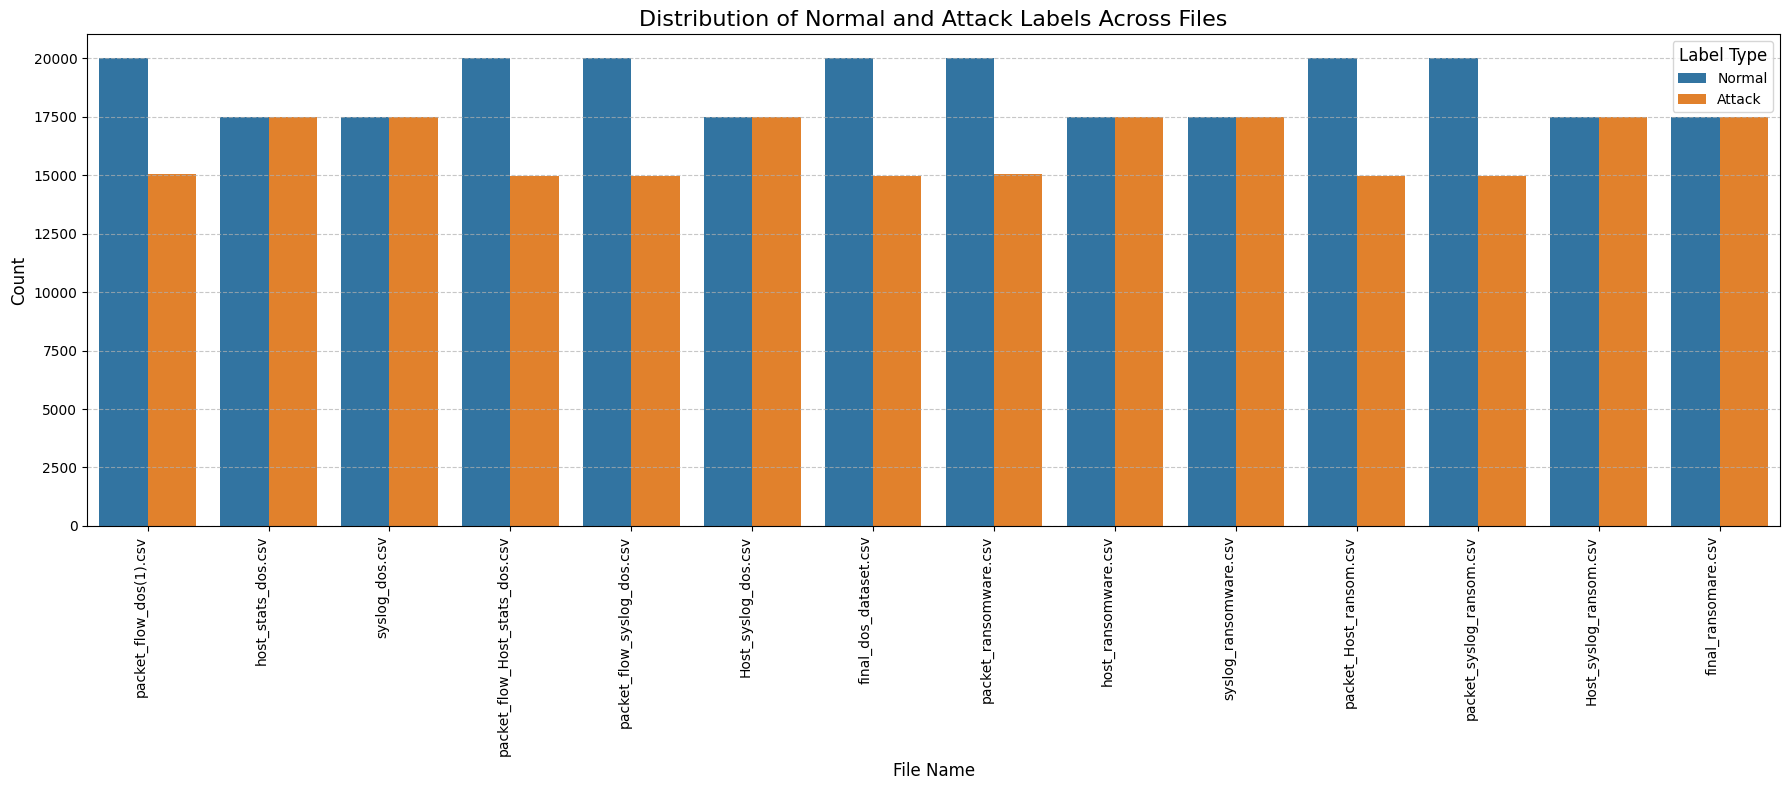

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to have 'Normal' and 'Attack' as a single column for plotting
df_melted = result.melt(id_vars=['File Name'], value_vars=['Normal', 'Attack'], var_name='Label Type', value_name='Count')

plt.figure(figsize=(18, 8)) # Increase figure size for better readability
sns.barplot(x='File Name', y='Count', hue='Label Type', data=df_melted)
plt.title('Distribution of Normal and Attack Labels Across Files', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Label Type', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
# Calculate the percentage of 'Attack' records
result['Attack Percentage'] = (result['Attack'] / result['Records']) * 100

# Display the updated DataFrame
display(result)

,File Name,Records,Features,Normal,Attack,Attack Percentage
0,packet_flow_dos(1).csv,35059,35,20019,15040,42.899113
1,host_stats_dos.csv,35000,4,17500,17500,50.000000
2,syslog_dos.csv,35000,6,17500,17500,50.000000
3,packet_flow_Host_stats_dos.csv,35000,40,20019,14981,42.802857
4,packet_flow_syslog_dos.csv,35000,42,20019,14981,42.802857
5,Host_syslog_dos.csv,35000,11,17500,17500,50.000000
6,final_dos_dataset.csv,35000,46,20019,14981,42.802857
7,packet_ransomware.csv,35059,35,20019,15040,42.899113
8,host_ransomware.csv,35000,7,17500,17500,50.000000
9,syslog_ransomware.csv,35000,6,17500,17500,50.000000


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

# Assuming 'files' and 'find_label_column' function are already defined from previous cells

results_summary = []

print("Starting model training and evaluation for each file...")

for file in files:
    print(f"\n{'='*50}\nProcessing file: {file}\n{'='*50}")
    try:
        df = pd.read_csv(os.path.join('/content/', file))

        # Drop 'Unnamed: 0' column if it exists
        if 'Unnamed: 0' in df.columns:
            df.drop(columns=['Unnamed: 0'], inplace=True)

        label_col = find_label_column(df)
        if not label_col:
            print(f"Skipping {file}: No label column found.")
            continue

        # Separate features (X) and target (y)
        X = df.drop(columns=[label_col])
        y = df[label_col]

        # Convert target to binary (0 for normal/benign, 1 for attack)
        y = y.apply(lambda x: 0 if str(x).lower() in ['0', 'normal', 'benign'] else 1)

        # Handle categorical features using one-hot encoding
        X = pd.get_dummies(X, drop_first=True)

        # Replace infinite values with NaN before imputation
        X = X.replace([np.inf, -np.inf], np.nan)

        # Handle missing values (impute with median for numerical features)
        # Median is chosen as it's more robust to outliers than the mean.
        X = X.fillna(X.median())

        # Ensure all column names are strings and valid for XGBoost
        X.columns = X.columns.astype(str)
        X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping {file}: Not enough classes in train or test set after split.")
            continue

        # Initialize and train Random Forest Classifier
        print("\n--- Random Forest Classifier ---")
        # Reduced n_estimators to simplify the model and potentially lower accuracy
        # Increased min_samples_leaf to make trees shallower and less specific
        rf_model = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1, min_samples_leaf=10)
        rf_model.fit(X_train, y_train)
        y_pred_rf = rf_model.predict(X_test)

        # Evaluate Random Forest
        accuracy_rf = accuracy_score(y_test, y_pred_rf)
        precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
        recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
        f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
        cm_rf = confusion_matrix(y_test, y_pred_rf)

        print(f"Accuracy: {accuracy_rf:.4f}")
        print(f"Precision: {precision_rf:.4f}")
        print(f"Recall: {recall_rf:.4f}")
        print(f"F1-Score: {f1_rf:.4f}")
        print("Confusion Matrix:\n", cm_rf)
        print("Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

        results_summary.append({
            "File Name": file,
            "Model": "Random Forest",
            "Accuracy": accuracy_rf,
            "Precision": precision_rf,
            "Recall": recall_rf,
            "F1-Score": f1_rf,
            "Confusion Matrix": cm_rf.tolist(), # Store as list for JSON compatibility
            "Feature Importances": dict(zip(X.columns, rf_model.feature_importances_)) # Store feature importances
        })

        # Initialize and train XGBoost Classifier
        print("\n--- XGBoost Classifier ---")
        # Increased min_child_weight and reduced max_depth to make the model more conservative and less complex
        xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1, min_child_weight=10, max_depth=3)
        xgb_model.fit(X_train, y_train)
        y_pred_xgb = xgb_model.predict(X_test)

        # Evaluate XGBoost
        accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
        precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
        recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
        f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
        cm_xgb = confusion_matrix(y_test, y_pred_xgb)

        print(f"Accuracy: {accuracy_xgb:.4f}")
        print(f"Precision: {precision_xgb:.4f}")
        print(f"Recall: {recall_xgb:.4f}")
        print(f"F1-Score: {f1_xgb:.4f}")
        print("Confusion Matrix:\n", cm_xgb)
        print("Classification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))

        results_summary.append({
            "File Name": file,
            "Model": "XGBoost",
            "Accuracy": accuracy_xgb,
            "Precision": precision_xgb,
            "Recall": recall_xgb,
            "F1-Score": f1_xgb,
            "Confusion Matrix": cm_xgb.tolist()
        })

    except Exception as e:
        print(f"An error occurred while processing {file}: {e}")
        results_summary.append({
            "File Name": file,
            "Model": "Error",
            "Details": str(e)
        })

print("\n--- Overall Model Evaluation Summary ---")
results_df = pd.DataFrame(results_summary)
display(results_df)

Starting model training and evaluation for each file...

Processing file: packet_flow_dos(1).csv

--- Random Forest Classifier ---
Accuracy: 0.9905
Precision: 0.9844
Recall: 0.9936
F1-Score: 0.9890
Confusion Matrix:
 [[5935   71]
 [  29 4483]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      6006
           1       0.98      0.99      0.99      4512

    accuracy                           0.99     10518
   macro avg       0.99      0.99      0.99     10518
weighted avg       0.99      0.99      0.99     10518


--- XGBoost Classifier ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9911
Precision: 0.9853
Recall: 0.9940
F1-Score: 0.9896
Confusion Matrix:
 [[5939   67]
 [  27 4485]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      6006
           1       0.99      0.99      0.99      4512

    accuracy                           0.99     10518
   macro avg       0.99      0.99      0.99     10518
weighted avg       0.99      0.99      0.99     10518


Processing file: host_stats_dos.csv

--- Random Forest Classifier ---
Accuracy: 0.8616
Precision: 0.9874
Recall: 0.7326
F1-Score: 0.8411
Confusion Matrix:
 [[5201   49]
 [1404 3846]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.99      0.88      5250
           1       0.99      0.73      0.84      5250

    accuracy                           0.86     10500
   macro avg       0.89      0.86      0.86     10500
weighted avg       0.89      0.86      0.86     10500




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Random Forest Classifier ---
Accuracy: 0.9071
Precision: 0.9460
Recall: 0.8636
F1-Score: 0.9029
Confusion Matrix:
 [[4991  259]
 [ 716 4534]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      5250
           1       0.95      0.86      0.90      5250

    accuracy                           0.91     10500
   macro avg       0.91      0.91      0.91     10500
weighted avg       0.91      0.91      0.91     10500


--- XGBoost Classifier ---


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9794
Precision: 0.9811
Recall: 0.9777
F1-Score: 0.9794
Confusion Matrix:
 [[5151   99]
 [ 117 5133]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      5250
           1       0.98      0.98      0.98      5250

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500


Processing file: final_ransomare.csv

--- Random Forest Classifier ---
Accuracy: 0.9758
Precision: 0.9733
Recall: 0.9785
F1-Score: 0.9759
Confusion Matrix:
 [[5109  141]
 [ 113 5137]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      5250
           1       0.97      0.98      0.98      5250

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9803
Precision: 0.9820
Recall: 0.9785
F1-Score: 0.9802
Confusion Matrix:
 [[5156   94]
 [ 113 5137]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      5250
           1       0.98      0.98      0.98      5250

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500


--- Overall Model Evaluation Summary ---


,File Name,Model,Accuracy,Precision,Recall,F1-Score,Confusion Matrix,Feature Importances
0,packet_flow_dos(1).csv,Random Forest,0.990492,0.984409,0.993573,0.988970,"[[5935, 71], [29, 4483]]","{'FlowDuration': 0.0048140742602285685, 'Total..."
1,packet_flow_dos(1).csv,XGBoost,0.991063,0.985281,0.994016,0.989629,"[[5939, 67], [27, 4485]]",NaN
2,host_stats_dos.csv,Random Forest,0.861619,0.987420,0.732571,0.841115,"[[5201, 49], [1404, 3846]]","{'cpu_usage': 0.07087226565977077, 'mem_usage'..."
3,host_stats_dos.csv,XGBoost,0.862286,0.988695,0.732952,0.841829,"[[5206, 44], [1402, 3848]]",NaN
4,syslog_dos.csv,Random Forest,0.907143,0.945963,0.863619,0.902917,"[[4991, 259], [716, 4534]]","{'login': 0.2849848362359338, 'failed_login': ..."
5,syslog_dos.csv,XGBoost,0.907143,0.945963,0.863619,0.902917,"[[4991, 259], [716, 4534]]",NaN
6,packet_flow_Host_stats_dos.csv,Random Forest,0.991429,0.986307,0.993769,0.990024,"[[5944, 62], [28, 4466]]","{'FlowDuration': 0.01796368294188241, 'TotalFw..."
7,packet_flow_Host_stats_dos.csv,XGBoost,0.991238,0.986947,0.992657,0.989794,"[[5947, 59], [33, 4461]]",NaN
8,packet_flow_syslog_dos.csv,Random Forest,0.993524,0.990905,0.993992,0.992446,"[[5965, 41], [27, 4467]]","{'FlowDuration': 0.019244364626766305, 'TotalF..."
9,packet_flow_syslog_dos.csv,XGBoost,0.993905,0.989611,0.996217,0.992903,"[[5959, 47], [17, 4477]]",NaN


In [ ]:
import pandas as pd

print("\n--- Random Forest Feature Importances ---")

for index, row in results_df[results_df['Model'] == 'Random Forest'].iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        print(f"\nFeature Importances for: {file_name} (Random Forest)")
        # Convert to DataFrame for better display and sorting
        importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df = importance_df.sort_values(by='Importance', ascending=False)
        display(importance_df.head(10)) # Display top 10 features
    else:
        print(f"\nNo feature importances found for {file_name} (Random Forest).")


--- Random Forest Feature Importances ---

Feature Importances for: packet_flow_dos(1).csv (Random Forest)


,Feature,Importance
4,TotalLengthofBwdPackets,0.134885
30,AvgBwdSegmentSize,0.126656
12,BwdPacketLengthStd,0.111040
11,BwdPacketLengthMean,0.076151
7,FwdPacketLengthMean,0.059144
22,FwdIATMax,0.055863
9,BwdPacketLengthMax,0.055325
32,SubflowFwdBytes,0.053420
33,SubflowBwdPackets,0.051402
34,SubflowBwdBytes,0.045593



Feature Importances for: host_stats_dos.csv (Random Forest)


,Feature,Importance
3,process_count,0.430222
2,disk_io,0.313704
1,mem_usage,0.185202
0,cpu_usage,0.070872



Feature Importances for: syslog_dos.csv (Random Forest)


...

,Feature,Importance
39,process_start,0.193266
37,file_access,0.175121
38,sudo_usage,0.149027
36,login_fail,0.145734
40,error_logs,0.130601
35,login_success,0.072032
0,FlowDuration,0.007717
9,FlowBytess,0.007695
11,FlowIATMean,0.006750
10,FlowPacketss,0.006523



Feature Importances for: Host_syslog_ransom.csv (Random Forest)


,Feature,Importance
2,Disk_Write,0.278160
0,CPU,0.220536
11,process_start,0.132071
8,login_fail,0.080647
1,Memory,0.063187
9,file_access,0.063160
10,sudo_usage,0.048186
12,error_logs,0.046459
3,Page_Faults,0.040960
7,login_success,0.022015



Feature Importances for: final_ransomare.csv (Random Forest)


,Feature,Importance
37,Disk_Write,0.339832
35,CPU,0.224844
44,file_access,0.083217
45,sudo_usage,0.076617
38,Page_Faults,0.067270
36,Memory,0.051141
47,error_logs,0.048902
46,process_start,0.046985
43,login_fail,0.020501
42,login_success,0.012598



--- Visualizing Random Forest Feature Importances ---


/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


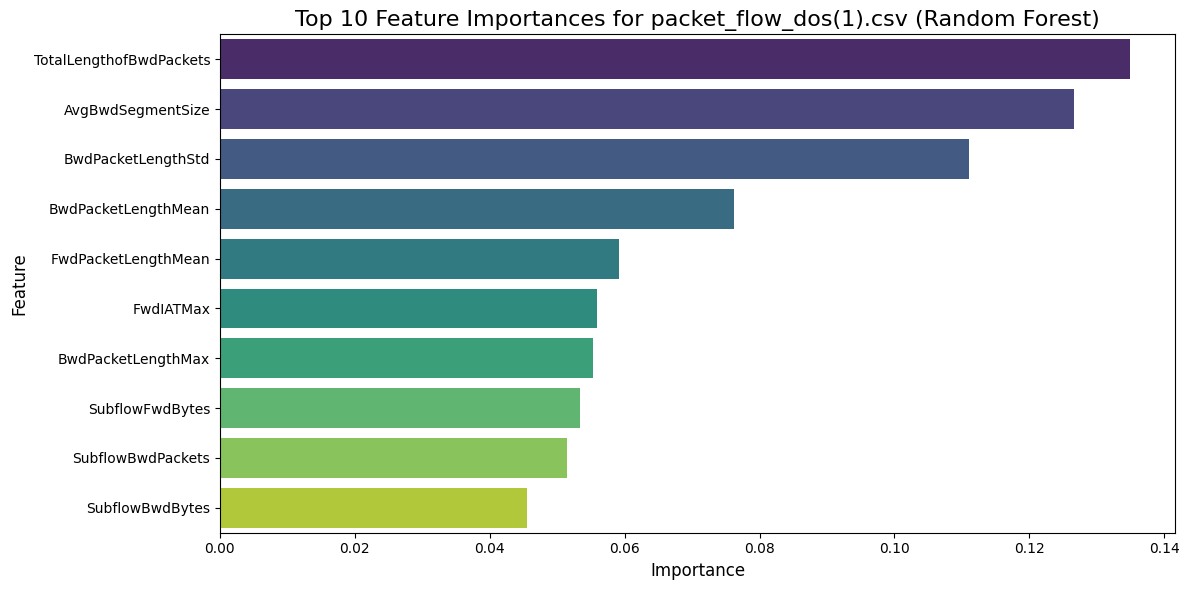

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


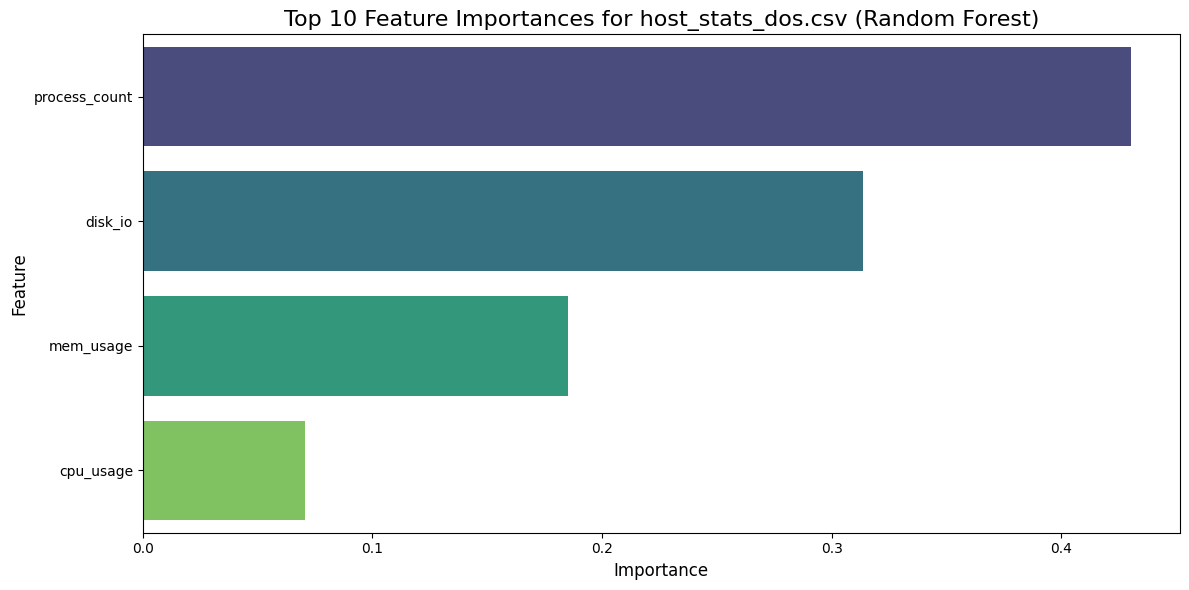

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


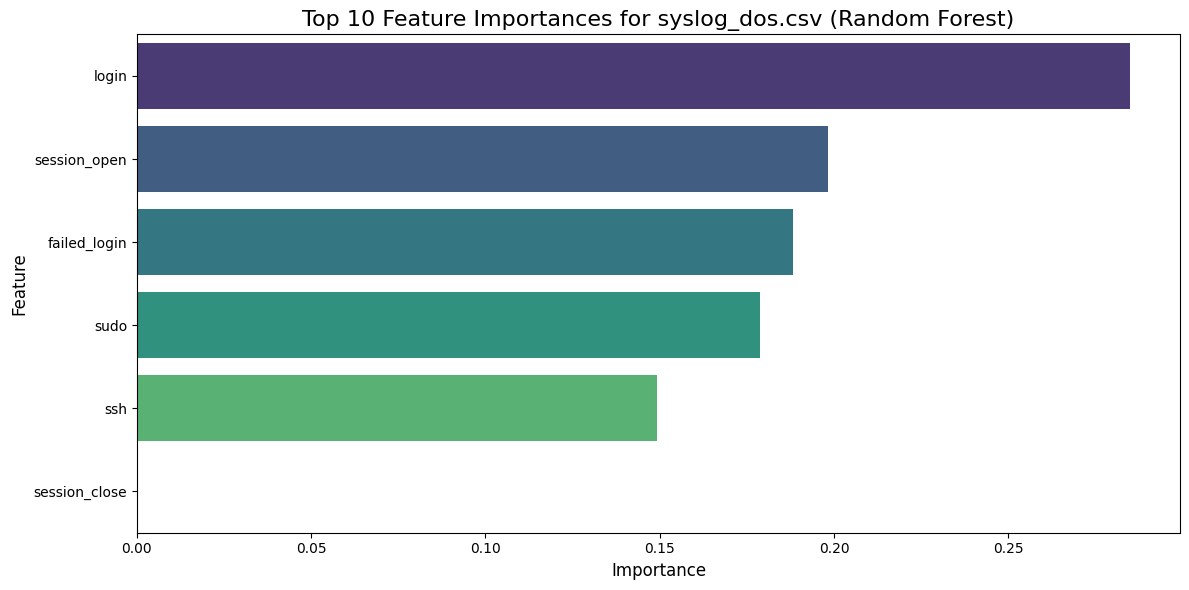

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


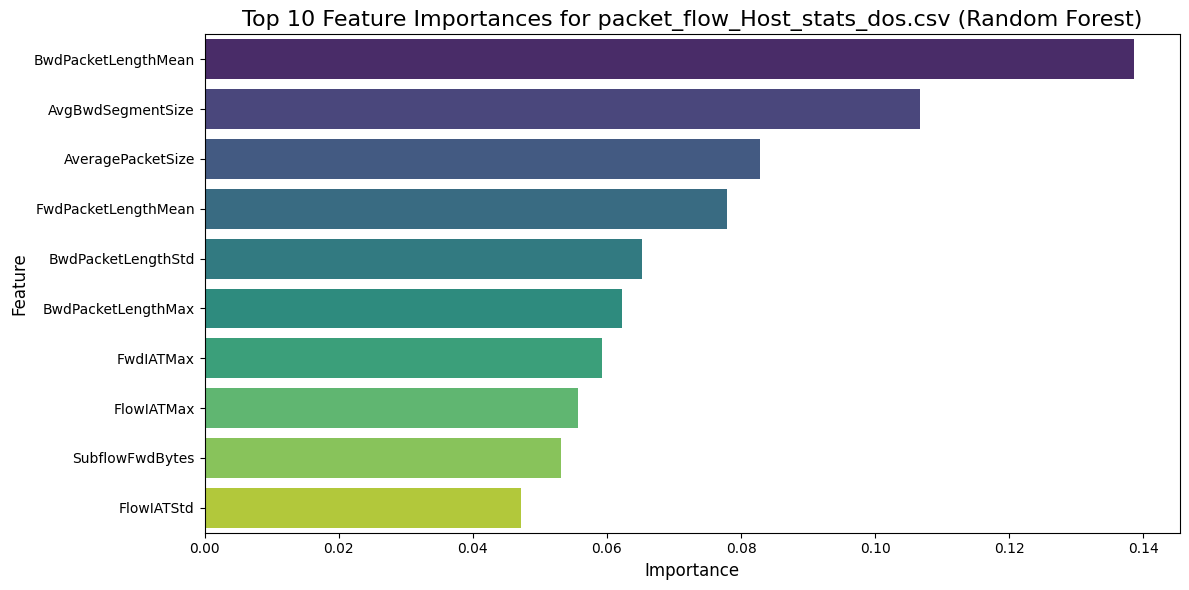

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


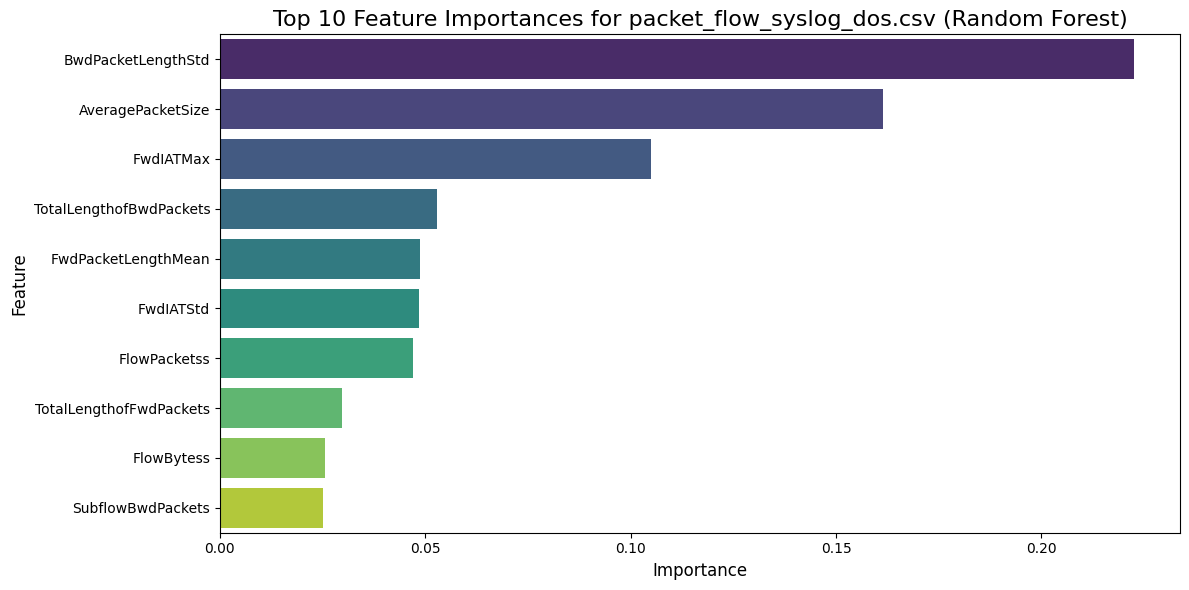

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


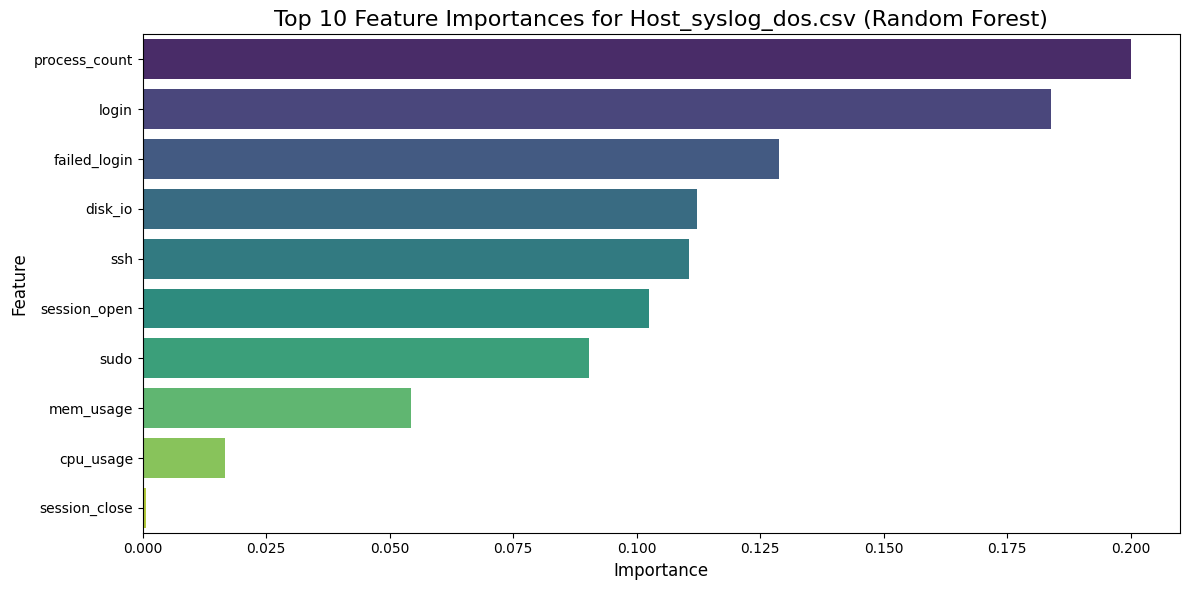

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


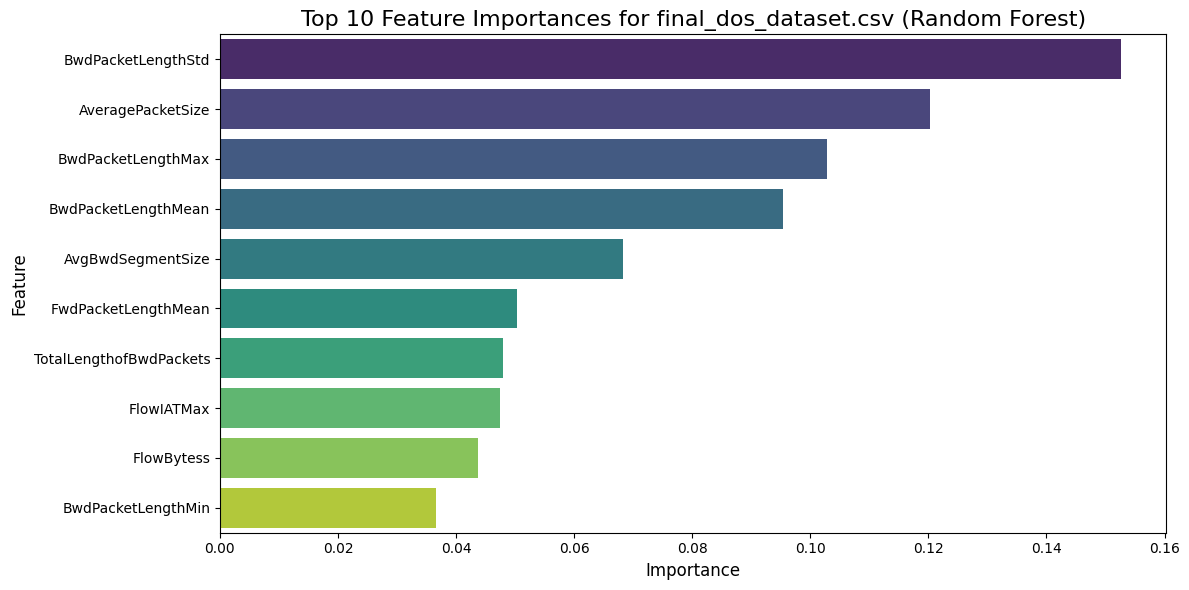

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


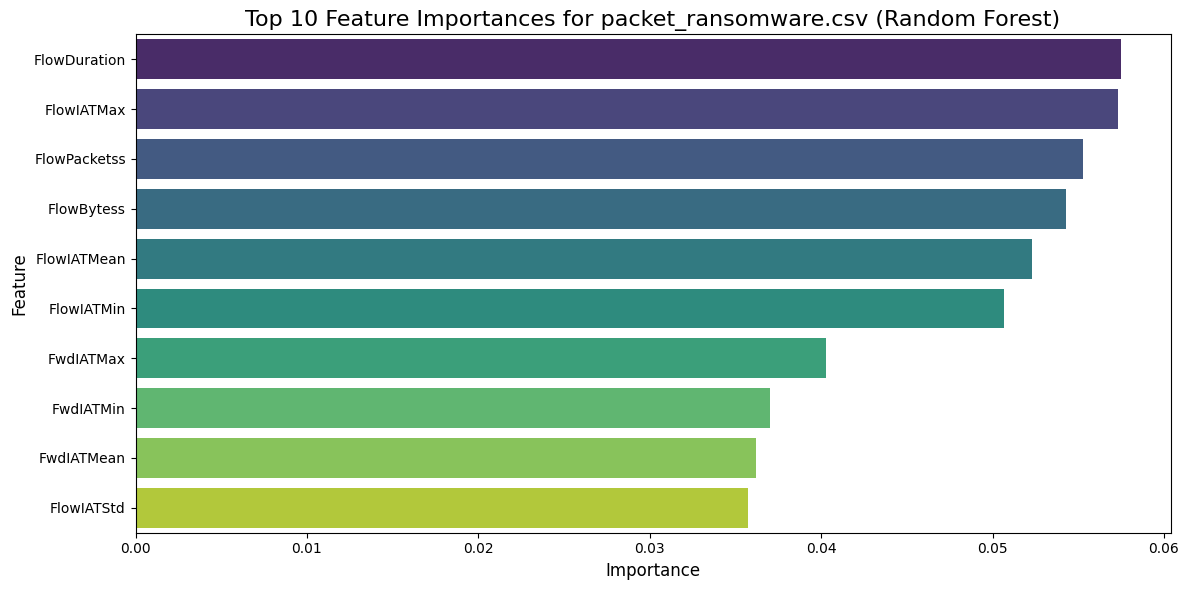

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


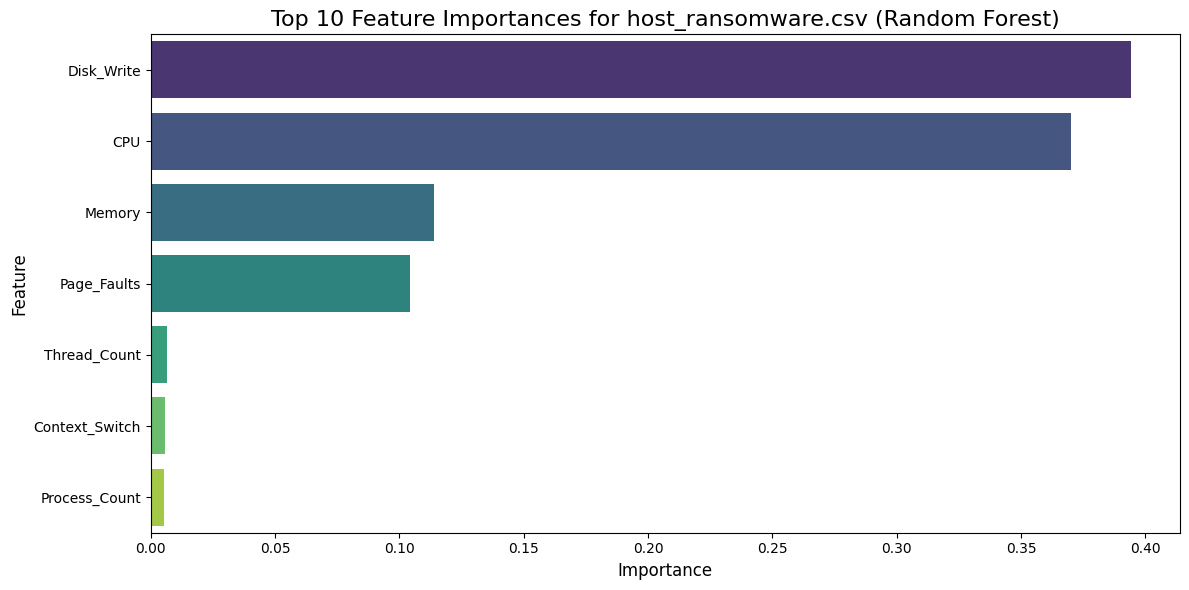

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


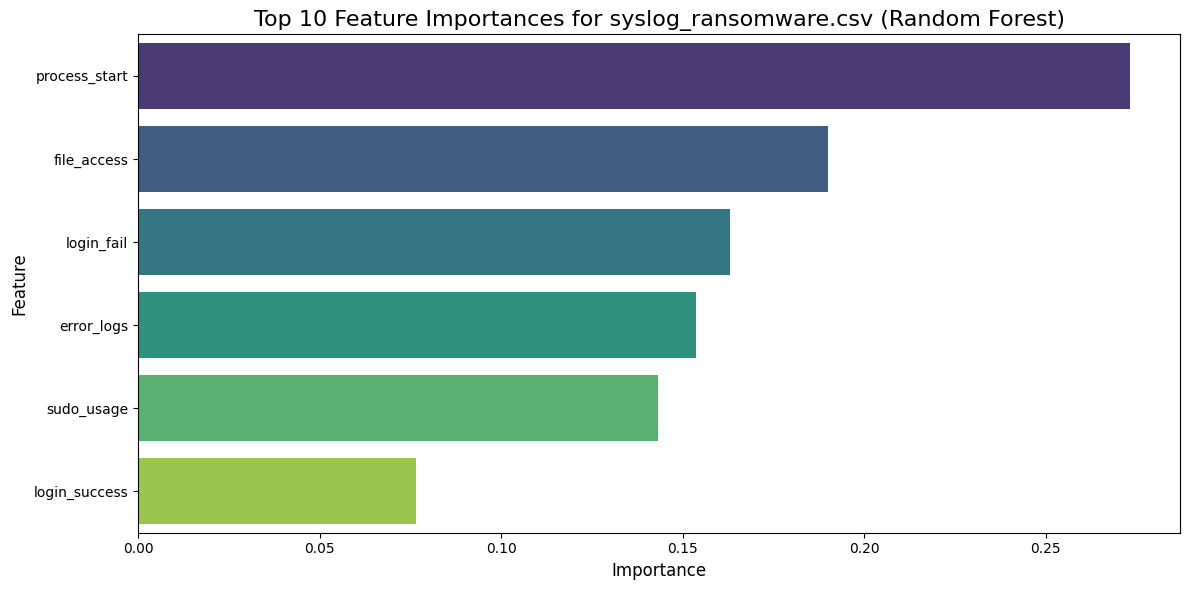

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


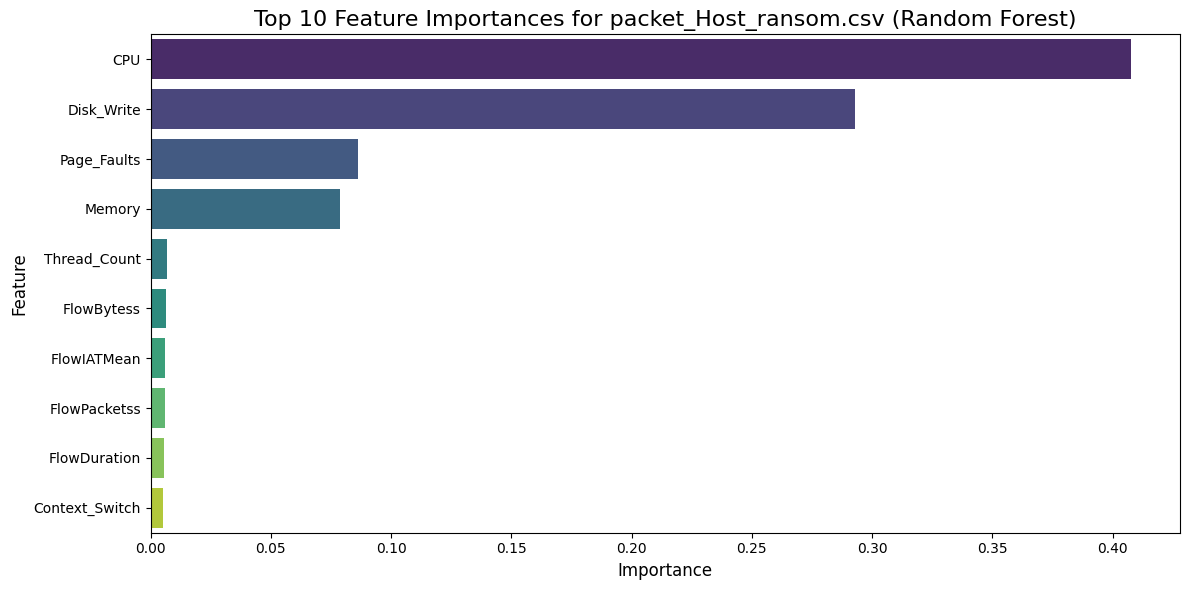

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


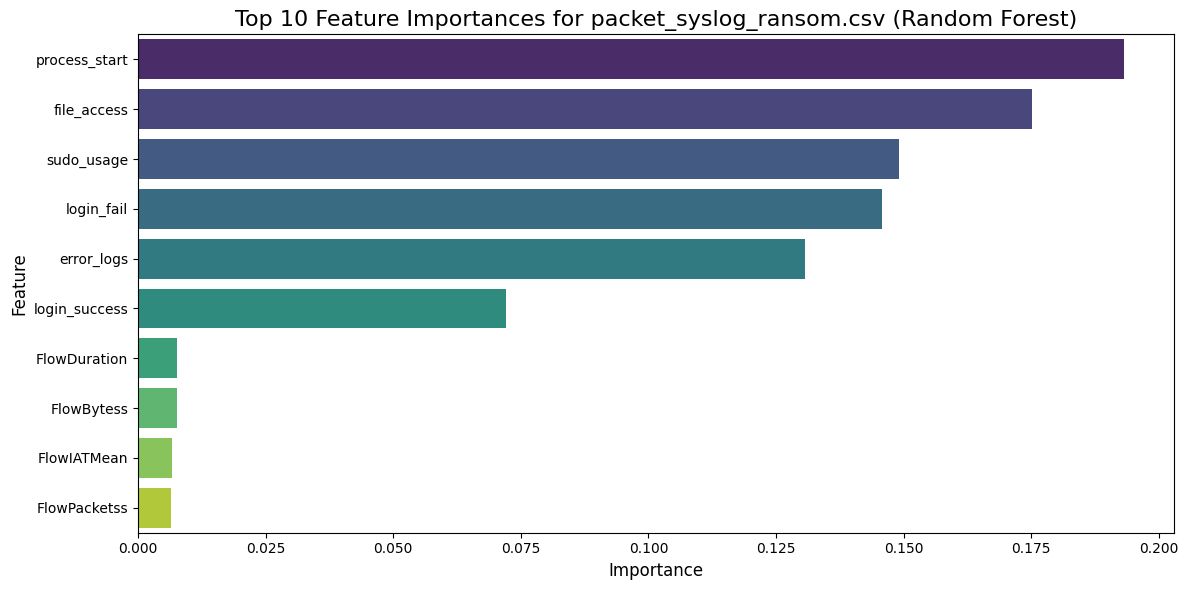

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


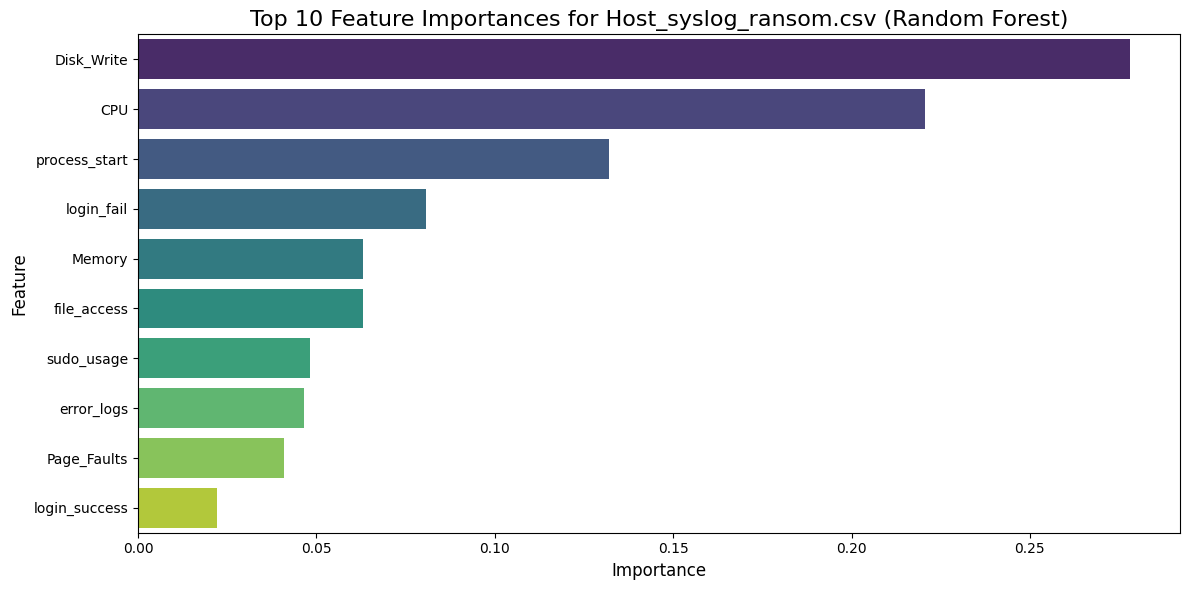

/tmp/ipykernel_6354/378332061.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


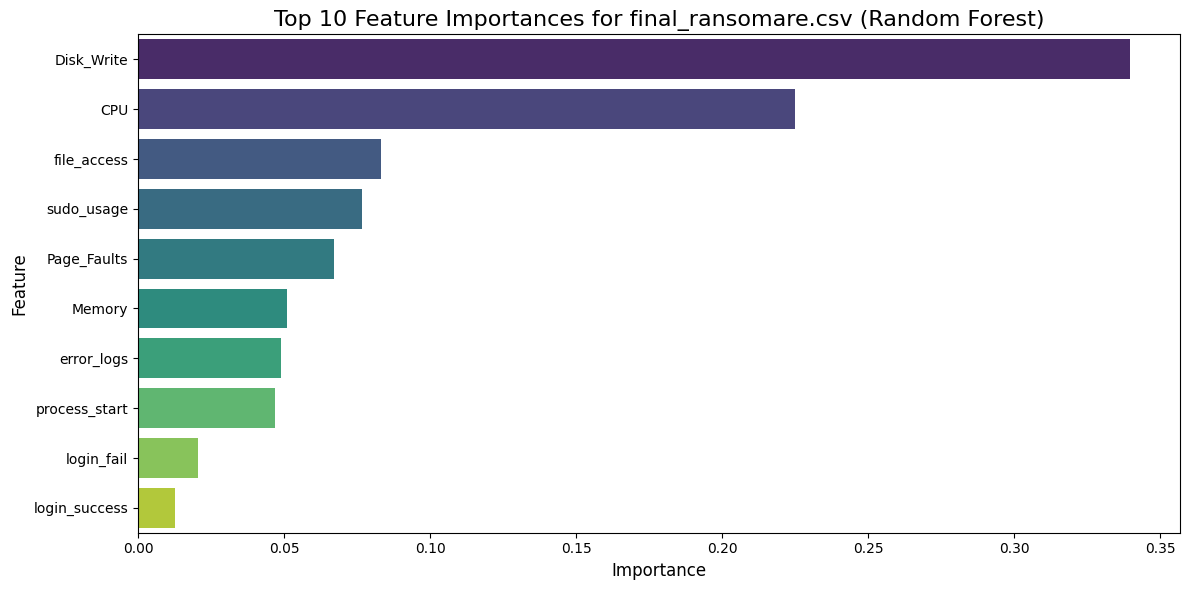

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Visualizing Random Forest Feature Importances ---")

for index, row in results_df[results_df['Model'] == 'Random Forest'].iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        # Convert to DataFrame for easier plotting and sorting
        importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

        plt.figure(figsize=(12, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
        plt.title(f'Top 10 Feature Importances for {file_name} (Random Forest)', fontsize=16)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nNo feature importances to plot for {file_name} (Random Forest).")

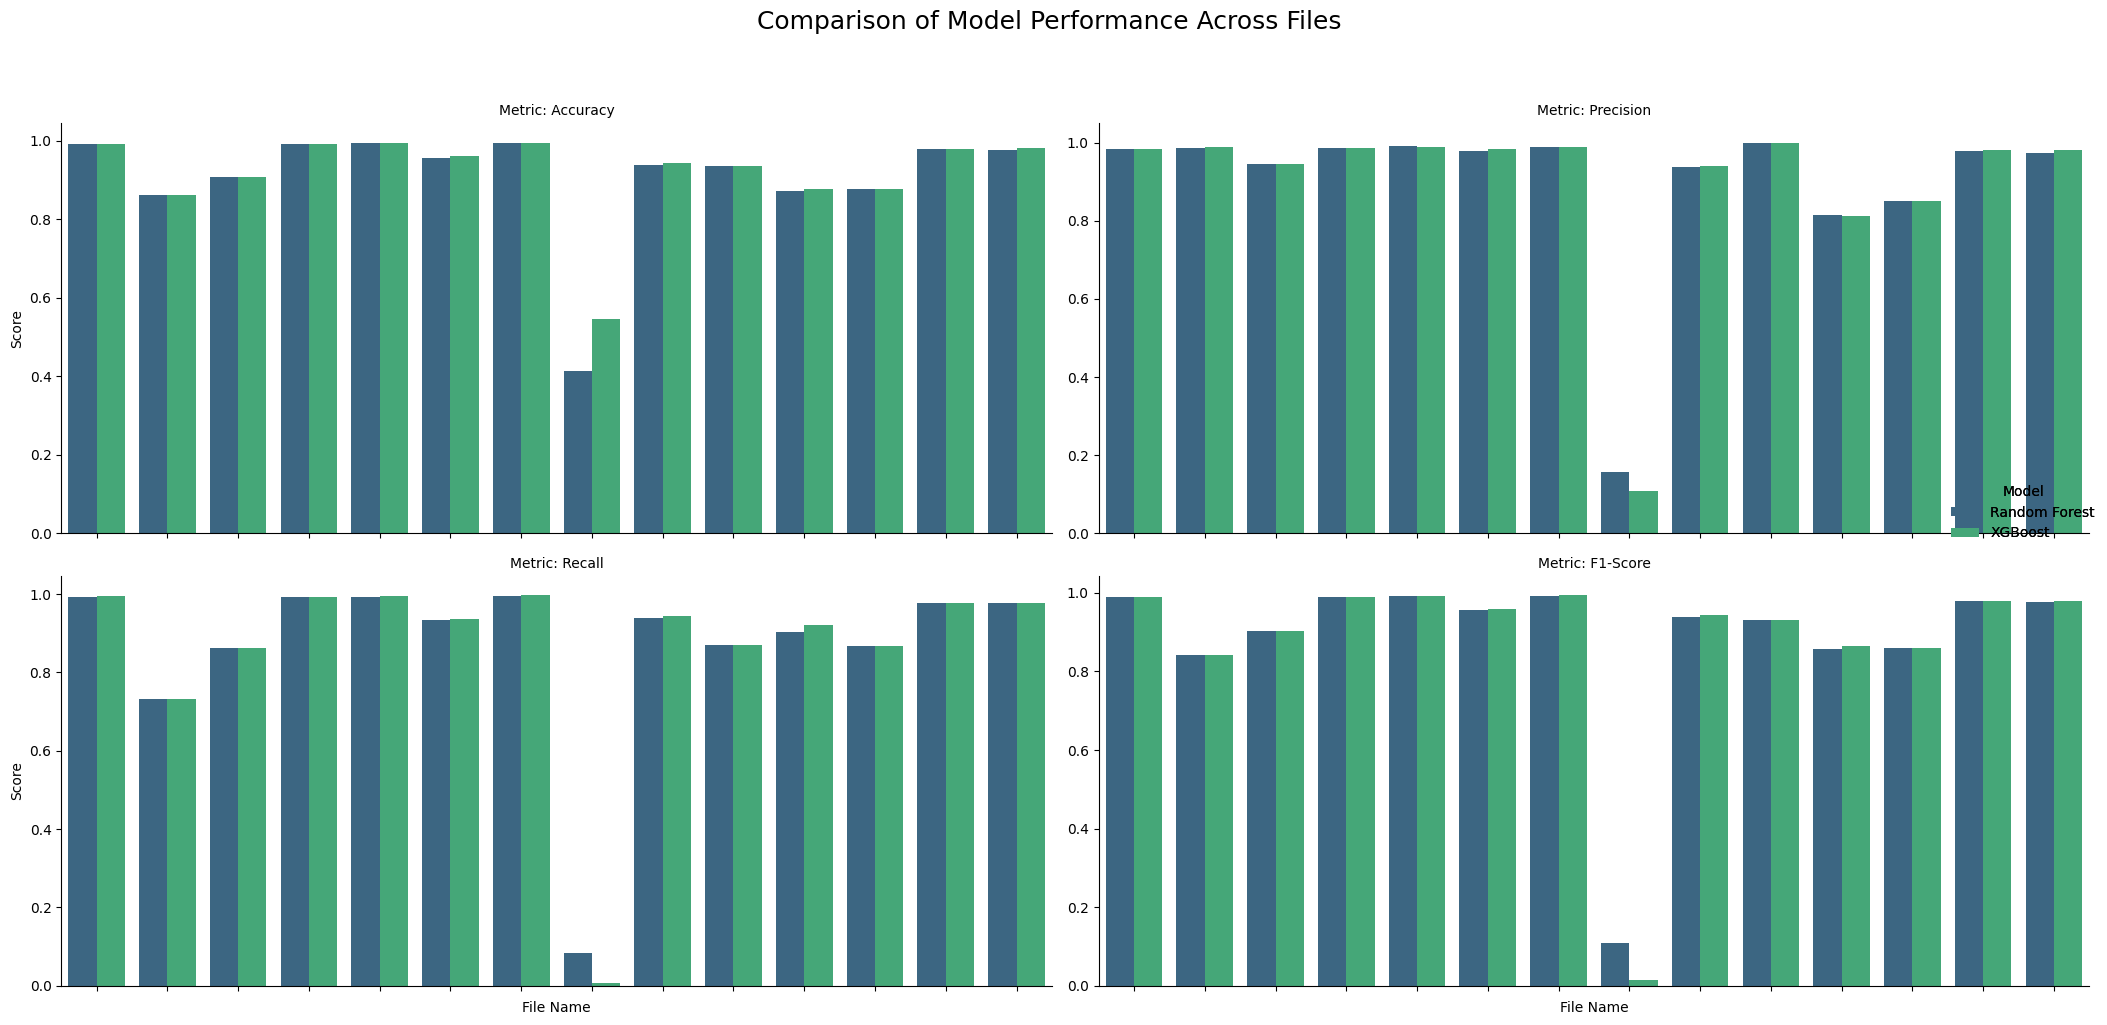

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out error rows for plotting
plot_df = results_df[results_df['Model'] != 'Error'].copy()

# Melt the DataFrame to prepare for plotting
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_melted_metrics = plot_df.melt(id_vars=['File Name', 'Model'], value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

# Use sns.catplot for faceting with 'col' and 'col_wrap'
g = sns.catplot(
    x='File Name',
    y='Score',
    hue='Model',
    col='Metric',
    data=df_melted_metrics,
    kind='bar',
    col_wrap=2,
    height=5,
    aspect=1.8,
    palette='viridis',
    sharey=False # Ensure y-axis scales are independent for different metrics
)

g.set_axis_labels('File Name', 'Score')
g.set_xticklabels(rotation=45, ha='right')
g.set_titles('Metric: {col_name}')
g.fig.suptitle('Comparison of Model Performance Across Files', y=1.02, fontsize=18) # Set suptitle on the FacetGrid figure
g.add_legend(title='Model')
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
print("\n--- Confusion Matrices for Final DoS and Ransomware Datasets ---")

for index, row in results_df.iterrows():
    file_name = row['File Name']
    model_name = row['Model']
    if file_name in ['final_dos_dataset.csv', 'final_ransomare.csv'] and model_name != 'Error':
        print(f"\nConfusion Matrix for {file_name} ({model_name}):")
        # Confusion matrix is stored as a list, convert back to numpy array for better display if needed, or just print
        cm = row['Confusion Matrix']
        if cm:
            # Displaying as is, or you could convert to a more formatted numpy array
            print(cm)
        else:
            print("No confusion matrix available.")


--- Confusion Matrices for Final DoS and Ransomware Datasets ---

Confusion Matrix for final_dos_dataset.csv (Random Forest):
[[5956, 50], [22, 4472]]

Confusion Matrix for final_dos_dataset.csv (XGBoost):
[[5963, 43], [15, 4479]]

Confusion Matrix for final_ransomare.csv (Random Forest):
[[5109, 141], [113, 5137]]

Confusion Matrix for final_ransomare.csv (XGBoost):
[[5156, 94], [113, 5137]]


### Model Performance for Final Datasets

Below are the performance metrics (Accuracy, Precision, Recall, F1-Score) for both Random Forest and XGBoost models on the `final_dos_dataset.csv` and `final_ransomare.csv`. This provides a concise overview of how well each model performed on these critical datasets.

In [ ]:
import pandas as pd

# Filter results for the final datasets
final_datasets_performance = results_df[
    (results_df['File Name'] == 'final_dos_dataset.csv') |
    (results_df['File Name'] == 'final_ransomare.csv')
].copy()

# Select relevant columns for display
performance_display = final_datasets_performance[[
    'File Name', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]]

print("#### Overall Model Performance on Final Datasets")
display(performance_display.round(4).to_markdown(index=False))

# You can also get the raw dataframe to copy/paste as a table:
# print(performance_display.round(4).to_string(index=False))

#### Overall Model Performance on Final Datasets


'| File Name             | Model         |   Accuracy |   Precision |   Recall |   F1-Score |\n|:----------------------|:--------------|-----------:|------------:|---------:|-----------:|\n| final_dos_dataset.csv | Random Forest |     0.9931 |      0.9889 |   0.9951 |     0.992  |\n| final_dos_dataset.csv | XGBoost       |     0.9945 |      0.9905 |   0.9967 |     0.9936 |\n| final_ransomare.csv   | Random Forest |     0.9758 |      0.9733 |   0.9785 |     0.9759 |\n| final_ransomare.csv   | XGBoost       |     0.9803 |      0.982  |   0.9785 |     0.9802 |'

### Top Feature Importances for Final Datasets (Random Forest)

These tables show the top 5 most important features identified by the Random Forest models for the `final_dos_dataset.csv` and `final_ransomare.csv`. These features were most influential in the models' predictions.

In [ ]:
import pandas as pd

# Filter for Random Forest models on final datasets
rf_final_datasets = results_df[
    ((results_df['File Name'] == 'final_dos_dataset.csv') |
     (results_df['File Name'] == 'final_ransomare.csv')) &
    (results_df['Model'] == 'Random Forest')
].copy()

for index, row in rf_final_datasets.iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        print(f"\n#### Top 5 Feature Importances for {file_name} (Random Forest)")
        # Convert to DataFrame for better display and sorting
        importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df = importance_df.sort_values(by='Importance', ascending=False).head(5)
        display(importance_df.round(4).to_markdown(index=False))
    else:
        print(f"\nNo feature importances found for {file_name} (Random Forest).")


#### Top 5 Feature Importances for final_dos_dataset.csv (Random Forest)


'| Feature             |   Importance |\n|:--------------------|-------------:|\n| BwdPacketLengthStd  |       0.1527 |\n| AveragePacketSize   |       0.1202 |\n| BwdPacketLengthMax  |       0.1028 |\n| BwdPacketLengthMean |       0.0953 |\n| AvgBwdSegmentSize   |       0.0683 |'


#### Top 5 Feature Importances for final_ransomare.csv (Random Forest)


'| Feature     |   Importance |\n|:------------|-------------:|\n| Disk_Write  |       0.3398 |\n| CPU         |       0.2248 |\n| file_access |       0.0832 |\n| sudo_usage  |       0.0766 |\n| Page_Faults |       0.0673 |'


--- Visualizing Top 5 Feature Importances Comparison ---


/tmp/ipykernel_6354/1863585765.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


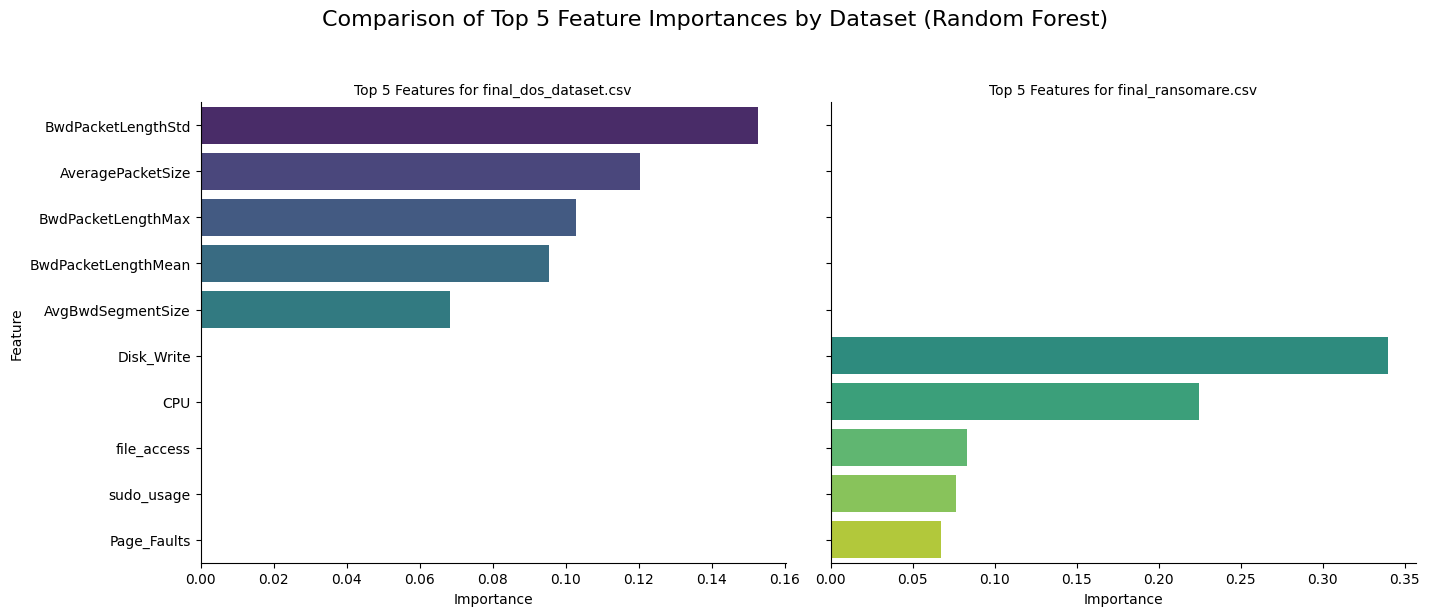

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- Visualizing Top 5 Feature Importances Comparison ---")

# Filter for Random Forest models on final datasets
rf_final_datasets = results_df[
    ((results_df['File Name'] == 'final_dos_dataset.csv') |
     (results_df['File Name'] == 'final_ransomare.csv')) &
    (results_df['Model'] == 'Random Forest')
].copy()

all_top_features = []

for index, row in rf_final_datasets.iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df = importance_df.sort_values(by='Importance', ascending=False).head(5)
        importance_df['Dataset'] = file_name # Add dataset identifier
        all_top_features.append(importance_df)

if all_top_features:
    combined_importance_df = pd.concat(all_top_features)

    g = sns.catplot(
        x='Importance',
        y='Feature',
        col='Dataset',
        data=combined_importance_df,
        kind='bar',
        col_wrap=2, # Display plots side-by-side if there are two datasets
        height=6,
        aspect=1.2,
        palette='viridis',
        sharex=False # Allow different x-axis scales for better readability
    )

    g.set_axis_labels('Importance', 'Feature')
    g.set_titles('Top 5 Features for {col_name}')
    g.fig.suptitle('Comparison of Top 5 Feature Importances by Dataset (Random Forest)', y=1.02, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
else:
    print("No feature importances found to compare for the final datasets.")

### Summary Table: Model Performance Comparison

This table presents the average performance metrics for Random Forest and XGBoost across all datasets, offering a high-level comparison of their overall effectiveness.

In [ ]:
import pandas as pd

# Filter out error rows and select relevant metrics
comparison_df = results_df[results_df['Model'] != 'Error'][[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]].copy()

# Group by model and calculate the mean for each metric
summary_comparison = comparison_df.groupby('Model').mean().round(4)

print("#### Average Performance Metrics by Model")
display(summary_comparison.to_markdown())

#### Average Performance Metrics by Model


'| Model         |   Accuracy |   Precision |   Recall |   F1-Score |\n|:--------------|-----------:|------------:|---------:|-----------:|\n| Random Forest |      0.906 |      0.8984 |   0.866  |     0.8794 |\n| XGBoost       |      0.917 |      0.8962 |   0.8628 |     0.8743 |'

### Box Plot: Accuracy Comparison Across Datasets

This box plot visualizes the distribution of accuracy scores for Random Forest and XGBoost models across all the evaluated datasets. It helps to understand the spread and central tendency of each model's performance.

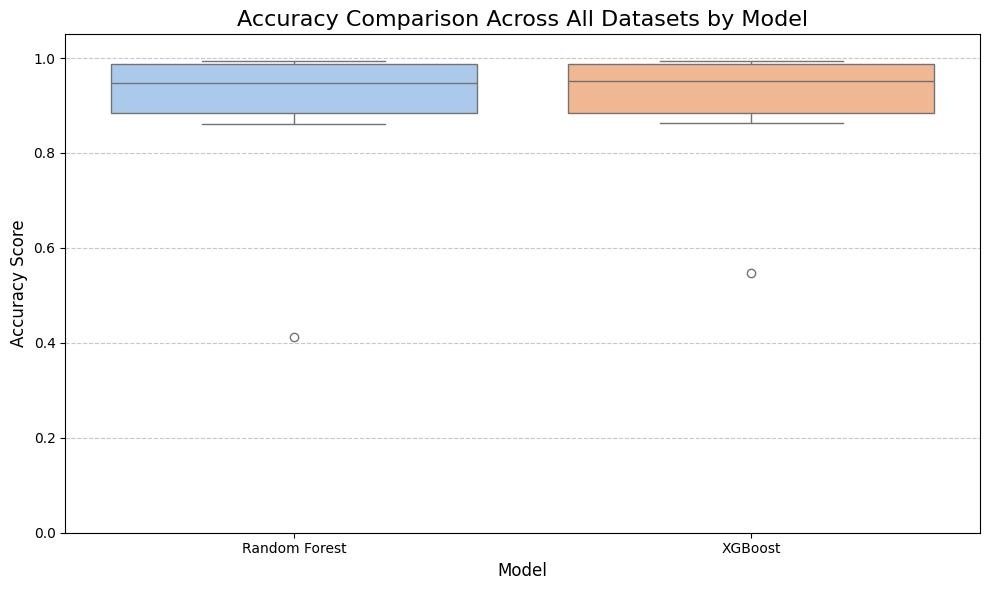

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out error rows for plotting
plot_accuracy_df = results_df[results_df['Model'] != 'Error'][['Model', 'Accuracy']].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Accuracy', data=plot_accuracy_df, palette='pastel', hue='Model', legend=False)
plt.title('Accuracy Comparison Across All Datasets by Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1 for accuracy scores
plt.tight_layout()
plt.show()

### Confusion Matrix Heatmaps for Random Forest Models

These heatmaps visualize the confusion matrices for each Random Forest model trained on the respective datasets. They help to understand the true positives, true negatives, false positives, and false negatives for each model.


--- Confusion Matrix Heatmaps for Random Forest Models ---


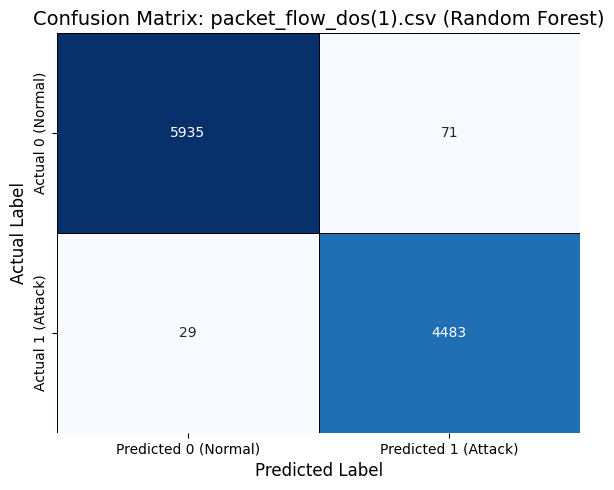

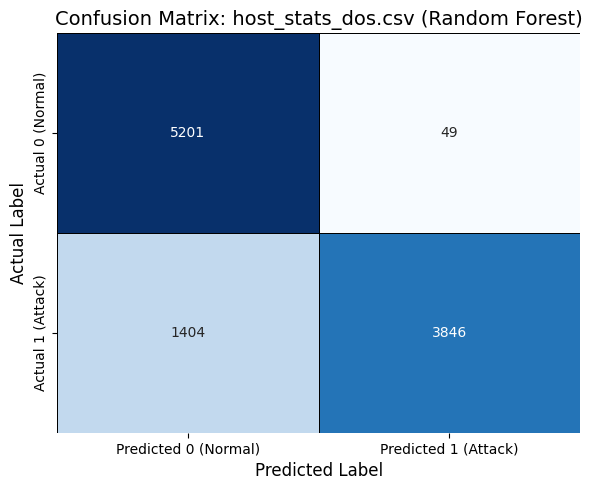

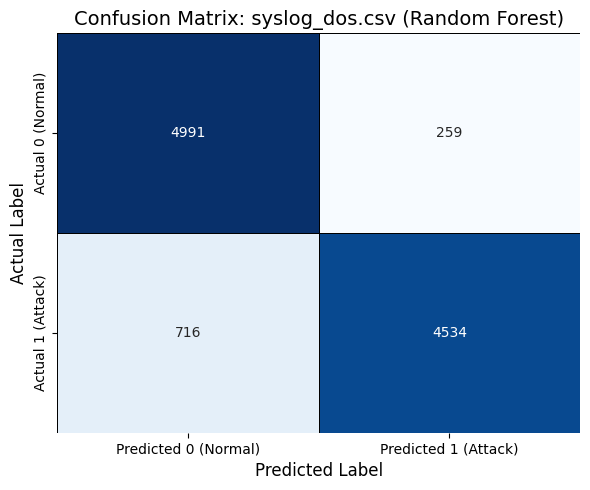

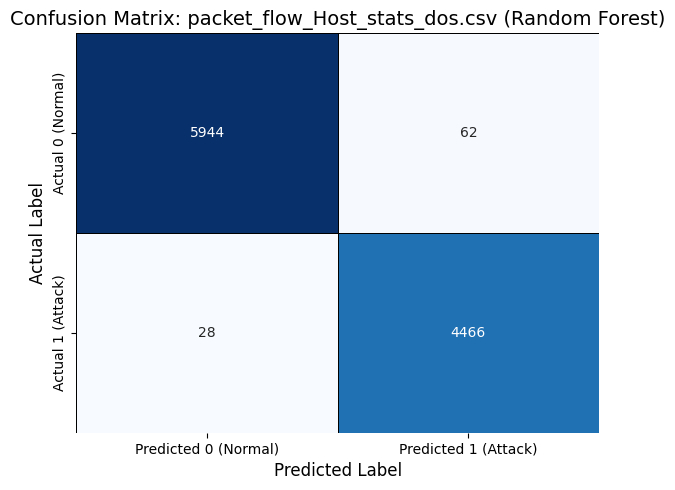

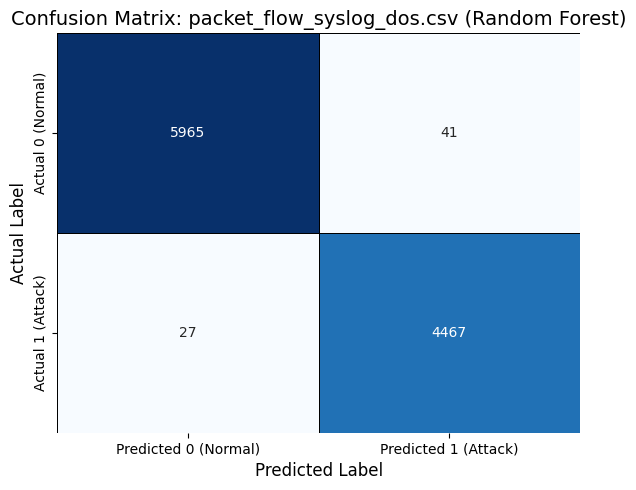

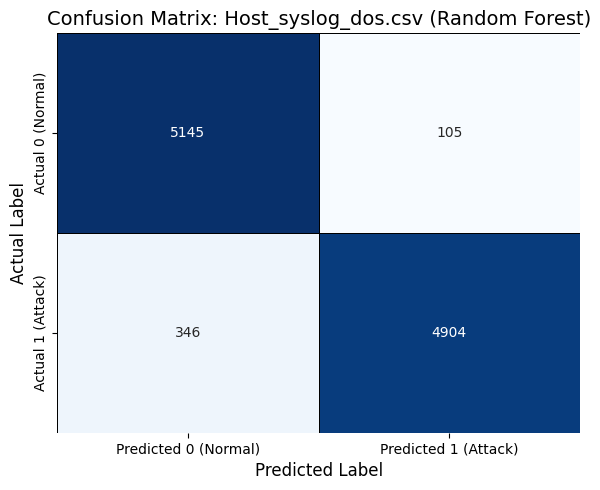

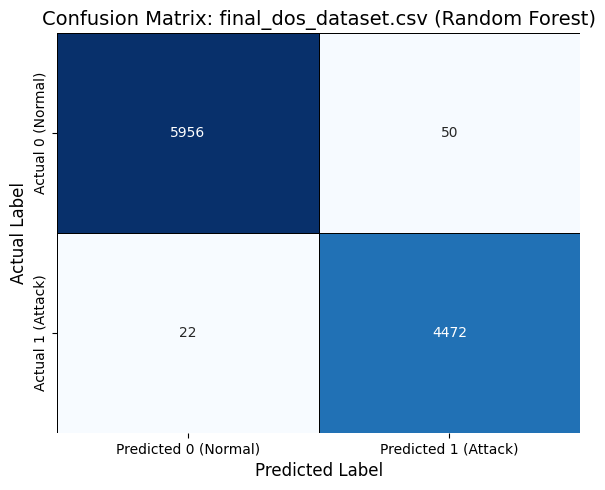

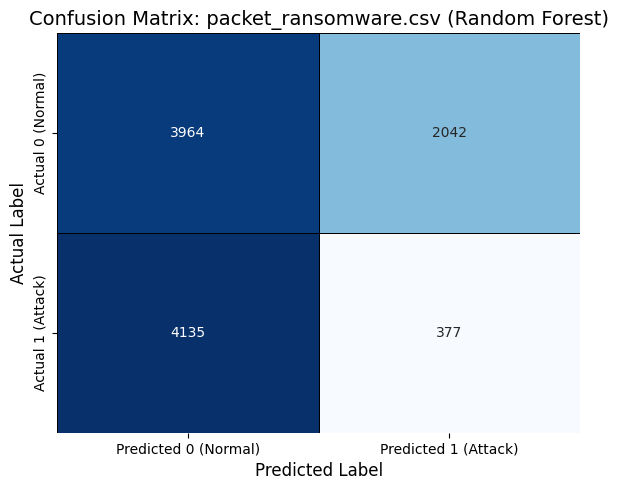

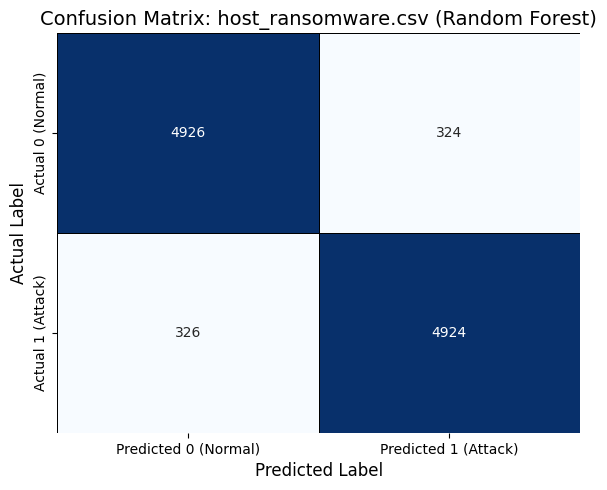

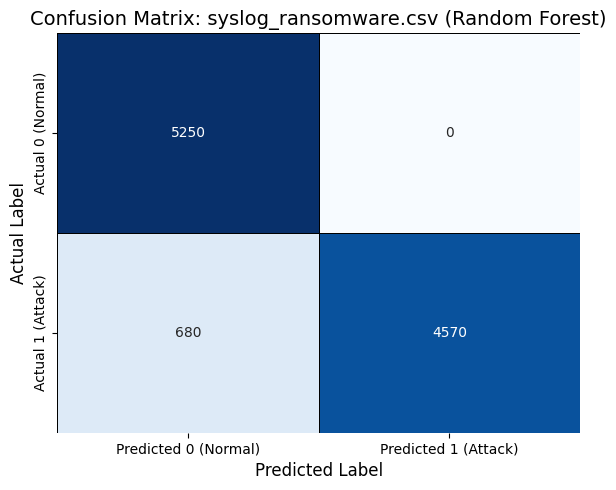

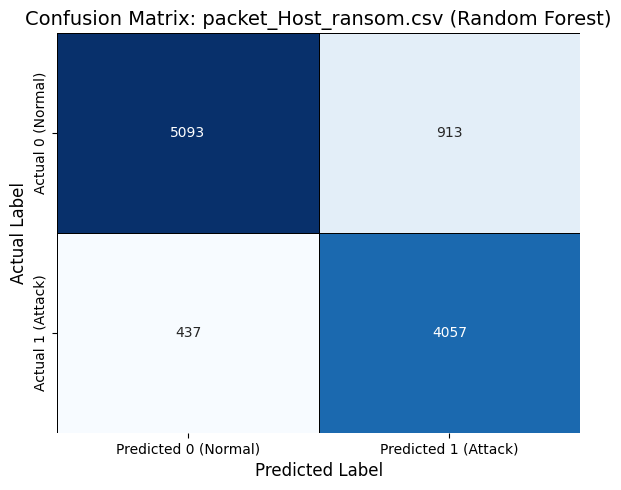

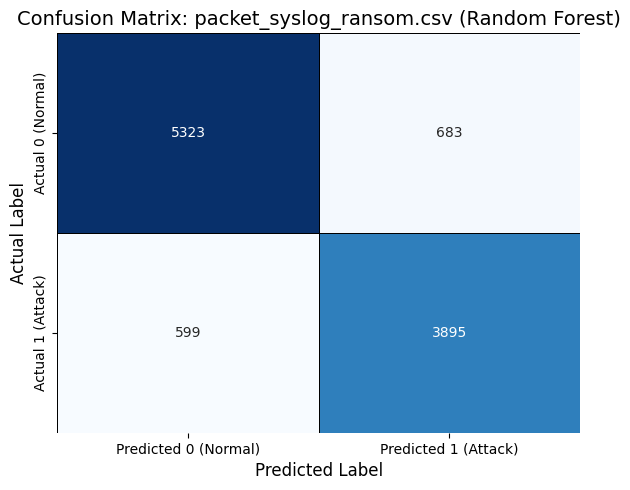

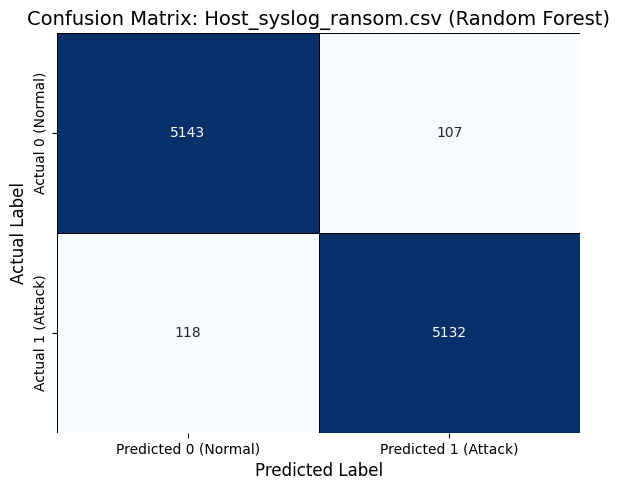

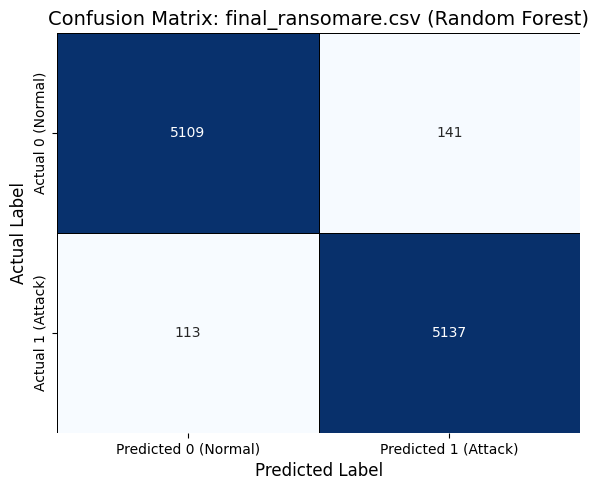

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Confusion Matrix Heatmaps for Random Forest Models ---")

# Filter results for Random Forest models
rf_results = results_df[results_df['Model'] == 'Random Forest'].copy()

for index, row in rf_results.iterrows():
    file_name = row['File Name']
    cm = row['Confusion Matrix']

    if cm and isinstance(cm, list) and len(cm) == 2 and all(isinstance(r, list) and len(r) == 2 for r in cm):
        cm_array = np.array(cm)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted 0 (Normal)', 'Predicted 1 (Attack)'],
                    yticklabels=['Actual 0 (Normal)', 'Actual 1 (Attack)'],
                    linewidths=.5, linecolor='black')
        plt.title(f'Confusion Matrix: {file_name} (Random Forest)', fontsize=14)
        plt.ylabel('Actual Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No valid confusion matrix found for {file_name} (Random Forest) or format is incorrect.")

### Summary Table: Confusion Matrix Metrics

This table presents a detailed breakdown of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) for each model across all datasets. This provides a granular view of each model's performance in terms of correct and incorrect classifications.

In [ ]:
import pandas as pd
import numpy as np

confusion_matrix_summary = []

for index, row in results_df.iterrows():
    file_name = row['File Name']
    model_name = row['Model']
    cm = row['Confusion Matrix']

    if cm and isinstance(cm, list) and len(cm) == 2 and all(isinstance(r, list) and len(r) == 2 for r in cm):
        tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

        confusion_matrix_summary.append({
            "File Name": file_name,
            "Model": model_name,
            "True Negatives (TN)": tn,
            "False Positives (FP)": fp,
            "False Negatives (FN)": fn,
            "True Positives (TP)": tp
        })
    elif model_name != 'Error': # Only report if it's not an already reported error
        confusion_matrix_summary.append({
            "File Name": file_name,
            "Model": model_name,
            "True Negatives (TN)": "N/A",
            "False Positives (FP)": "N/A",
            "False Negatives (FN)": "N/A",
            "True Positives (TP)": "N/A",
            "Details": "Invalid or missing Confusion Matrix"
        })

cm_summary_df = pd.DataFrame(confusion_matrix_summary)
print("#### Confusion Matrix Metrics Across Datasets")
display(cm_summary_df.to_markdown(index=False))

#### Confusion Matrix Metrics Across Datasets


'| File Name                      | Model         |   True Negatives (TN) |   False Positives (FP) |   False Negatives (FN) |   True Positives (TP) |\n|:-------------------------------|:--------------|----------------------:|-----------------------:|-----------------------:|----------------------:|\n| packet_flow_dos(1).csv         | Random Forest |                  5935 |                     71 |                     29 |                  4483 |\n| packet_flow_dos(1).csv         | XGBoost       |                  5939 |                     67 |                     27 |                  4485 |\n| host_stats_dos.csv             | Random Forest |                  5201 |                     49 |                   1404 |                  3846 |\n| host_stats_dos.csv             | XGBoost       |                  5206 |                     44 |                   1402 |                  3848 |\n| syslog_dos.csv                 | Random Forest |                  4991 |                    259 |

### Bar Chart: Average Accuracy Comparison

This bar chart visually compares the average accuracy scores of Random Forest and XGBoost models across all datasets, providing a clear high-level view of their performance relative to each other.

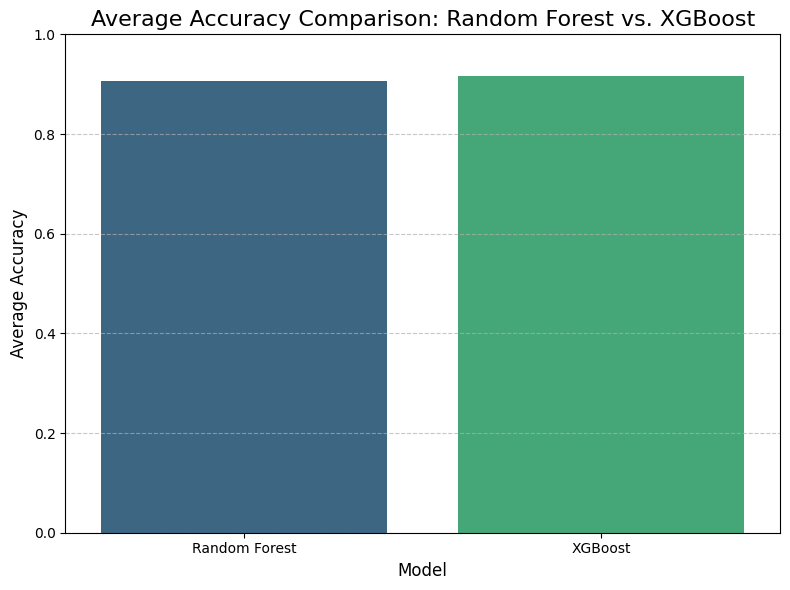

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure summary_comparison DataFrame is available and correctly structured
# If it's not from previous execution, re-create it for robustness
if 'summary_comparison' not in locals():
    comparison_df = results_df[results_df['Model'] != 'Error'][[
        'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
    ]].copy()
    summary_comparison = comparison_df.groupby('Model').mean().round(4)

plt.figure(figsize=(8, 6))
sns.barplot(x=summary_comparison.index, y='Accuracy', data=summary_comparison, palette='viridis', hue=summary_comparison.index, legend=False)
plt.title('Average Accuracy Comparison: Random Forest vs. XGBoost', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average Accuracy', fontsize=12)
plt.ylim(0, 1.0) # Set y-axis limit for accuracy scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure summary_comparison DataFrame is available and correctly structured
# If it's not from previous execution, re-create it for robustness
if 'summary_comparison' not in locals():
    comparison_df = results_df[results_df['Model'] != 'Error'][[
        'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
    ]].copy()
    summary_comparison = comparison_df.groupby('Model').mean().round(4)

plt.figure(figsize=(8, 6))
sns.barplot(x=summary_comparison.index, y='Accuracy', data=summary_comparison, palette='viridis', hue=summary_comparison.index, legend=False)
plt.title('Average Accuracy Comparison: Random Forest vs. XGBoost', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average Accuracy', fontsize=12)
plt.ylim(0, 1.0) # Set y-axis limit for accuracy scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("Average Accuracy Comparison bar chart displayed.")

### Single vs Multi-source Performance Comparison

This section compares the performance of the models when trained on single-source datasets versus multi-source (combined) datasets. This helps to understand if combining data from different sources improves model robustness and accuracy.

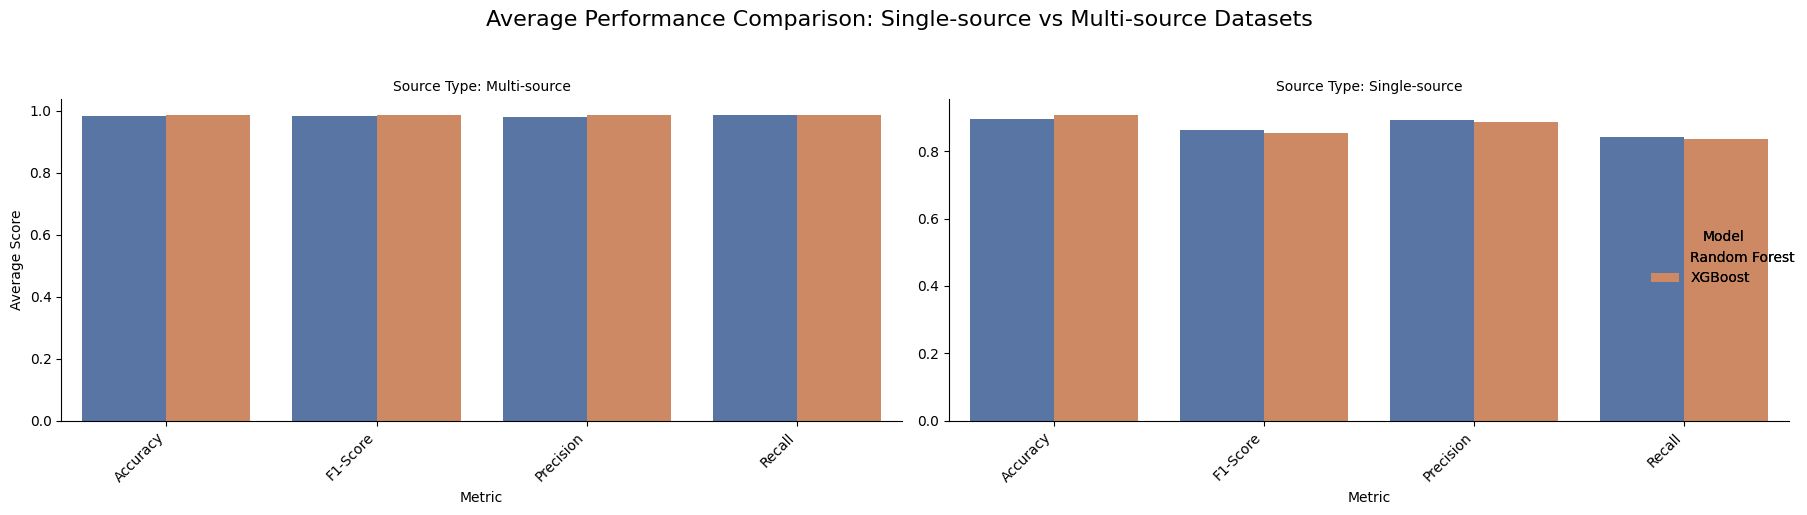

Single vs Multi-source Performance Comparison plots displayed.


In [ ]:
import re

# Function to determine if a file is single-source or multi-source
def get_source_type(file_name):
    # Patterns for single sources (e.g., packet, host, syslog)
    single_source_patterns = [
        r'packet_flow', r'host_stats', r'syslog', r'packet_ransomware', r'host_ransomware', r'syslog_ransomware'
    ]
    # Patterns indicating combinations (e.g., Host_stats, syslog, final)
    multi_source_keywords = [
        'Host_stats', 'syslog', 'final', 'packet_Host', 'Host_syslog'
    ]

    # Normalize file name for easier matching
    normalized_file_name = file_name.lower().replace('.csv', '')

    # Check for multi-source keywords in the name
    if any(keyword in normalized_file_name for keyword in multi_source_keywords if keyword != 'syslog'):
        # More specific checks for known multi-source files
        if ('packet_flow' in normalized_file_name and ('host_stats' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host_stats' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('packet' in normalized_file_name and ('host' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('final' in normalized_file_name):
            return 'Multi-source'

    # Check for single-source patterns
    for pattern in single_source_patterns:
        if re.search(pattern, normalized_file_name) and not any(k in normalized_file_name for k in multi_source_keywords if k != 'syslog' and k not in pattern): # Ensure not a compound name
            return 'Single-source'

    return 'Unknown' # Default if not clearly classified

# Apply the function to create a new 'Source Type' column
results_df_classified = results_df.copy()
results_df_classified['Source Type'] = results_df_classified['File Name'].apply(get_source_type)

# Filter out 'Error' rows and 'Unknown' source types for meaningful comparison
plot_df_classified = results_df_classified[results_df_classified['Model'] != 'Error'].copy()
plot_df_classified = plot_df_classified[plot_df_classified['Source Type'] != 'Unknown']

# Melt the DataFrame for plotting performance metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_melted_source_comparison = plot_df_classified.melt(
    id_vars=['File Name', 'Model', 'Source Type'],
    value_vars=metrics_to_plot,
    var_name='Metric',
    value_name='Score'
)

# Calculate average scores for each Source Type and Model
mean_performance_by_source = df_melted_source_comparison.groupby(['Source Type', 'Model', 'Metric'])['Score'].mean().reset_index()

# Plotting
g = sns.catplot(
    x='Metric',
    y='Score',
    hue='Model',
    col='Source Type',
    data=mean_performance_by_source,
    kind='bar',
    col_wrap=2,
    height=5,
    aspect=1.5,
    palette='deep',
    sharey=False
)

g.set_axis_labels('Metric', 'Average Score')
g.set_xticklabels(rotation=45, ha='right')
g.set_titles('Source Type: {col_name}')
g.fig.suptitle('Average Performance Comparison: Single-source vs Multi-source Datasets', y=1.02, fontsize=16)
g.add_legend(title='Model')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("Single vs Multi-source Performance Comparison plots displayed.")

### Accuracy Comparison for Final DoS Dataset

This bar chart visualizes the accuracy scores of Random Forest and XGBoost models specifically for the `final_dos_dataset.csv`.

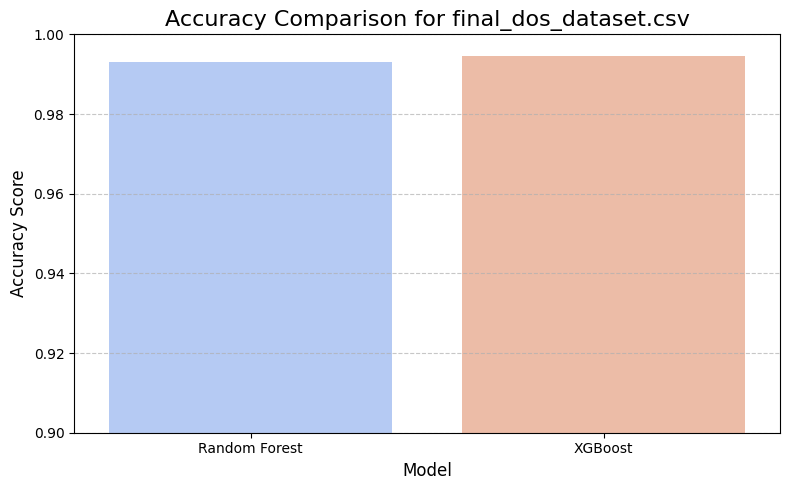

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for final_dos_dataset.csv
dos_accuracy = results_df[(results_df['File Name'] == 'final_dos_dataset.csv') & (results_df['Model'] != 'Error')]

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=dos_accuracy, palette='coolwarm', hue='Model', legend=False)
plt.title('Accuracy Comparison for final_dos_dataset.csv', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.9, 1.0) # Set y-axis limits to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Accuracy Comparison for Final Ransomware Dataset

This bar chart visualizes the accuracy scores of Random Forest and XGBoost models specifically for the `final_ransomare.csv`.

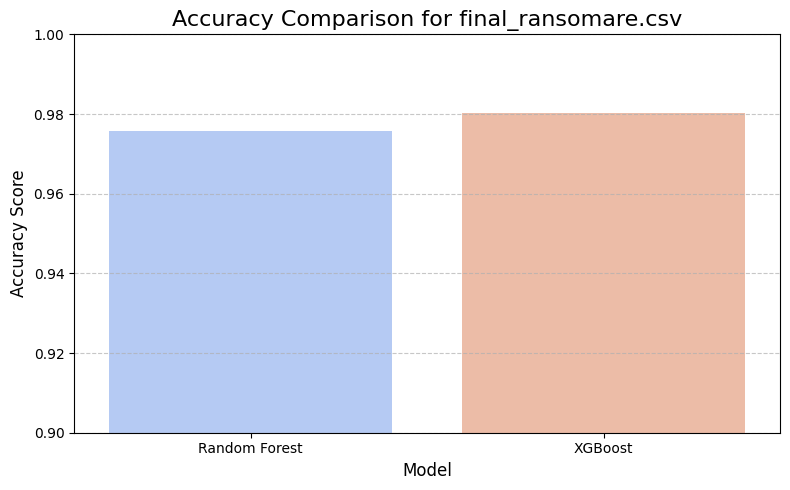

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for final_ransomare.csv
ransom_accuracy = results_df[(results_df['File Name'] == 'final_ransomare.csv') & (results_df['Model'] != 'Error')]

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=ransom_accuracy, palette='coolwarm', hue='Model', legend=False)
plt.title('Accuracy Comparison for final_ransomare.csv', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.9, 1.0) # Set y-axis limits to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Accuracy Comparison for All DoS Datasets

This bar chart visualizes the accuracy scores of Random Forest and XGBoost models across all individual DoS-related datasets.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter results for all 'dos' files and valid models
dos_files_pattern = ['dos'] # Files containing 'dos' in their name
dos_performance_df = results_df[
    results_df['File Name'].str.contains('|'.join(dos_files_pattern), case=False, regex=True) &
    (results_df['Model'] != 'Error')
].copy()

plt.figure(figsize=(15, 7))
sns.barplot(x='File Name', y='Accuracy', hue='Model', data=dos_performance_df, palette='viridis')
plt.title('Accuracy Comparison for All DoS Datasets', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(dos_performance_df['Accuracy'].min() * 0.95, 1.05) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print("Accuracy Comparison for All DoS Datasets bar chart displayed.")

### Average Accuracy: Single-source vs Multi-source Comparison

This bar chart focuses specifically on the average accuracy of models when trained on single-source versus multi-source datasets.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure `results_df_classified` and `mean_performance_by_source` are available
# If not, regenerate the classification and aggregation steps (from cell f4f91865)
# For robustness, we will ensure these are calculated if not already in session

# Function to determine if a file is single-source or multi-source (re-using for robustness)
def get_source_type(file_name):
    single_source_patterns = [
        r'packet_flow', r'host_stats', r'syslog', r'packet_ransomware', r'host_ransomware', r'syslog_ransomware'
    ]
    multi_source_keywords = [
        'Host_stats', 'syslog', 'final', 'packet_Host', 'Host_syslog'
    ]
    normalized_file_name = file_name.lower().replace('.csv', '')

    if any(keyword in normalized_file_name for keyword in multi_source_keywords if keyword != 'syslog'):
        if ('packet_flow' in normalized_file_name and ('host_stats' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host_stats' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('packet' in normalized_file_name and ('host' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('final' in normalized_file_name):
            return 'Multi-source'

    for pattern in single_source_patterns:
        if re.search(pattern, normalized_file_name) and not any(k in normalized_file_name for k in multi_source_keywords if k != 'syslog' and k not in pattern):
            return 'Single-source'
    return 'Unknown'

# Re-apply classification and aggregation for robustness if needed
if 'results_df_classified' not in locals():
    results_df_classified = results_df.copy()
    results_df_classified['Source Type'] = results_df_classified['File Name'].apply(get_source_type)
    plot_df_classified = results_df_classified[results_df_classified['Model'] != 'Error'].copy()
    plot_df_classified = plot_df_classified[plot_df_classified['Source Type'] != 'Unknown']
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    df_melted_source_comparison = plot_df_classified.melt(
        id_vars=['File Name', 'Model', 'Source Type'],
        value_vars=metrics_to_plot,
        var_name='Metric',
        value_name='Score'
    )
    mean_performance_by_source = df_melted_source_comparison.groupby(['Source Type', 'Model', 'Metric'])['Score'].mean().reset_index()

# Filter for Accuracy from the aggregated data
accuracy_by_source = mean_performance_by_source[mean_performance_by_source['Metric'] == 'Accuracy'].copy()

plt.figure(figsize=(10, 6))
sns.barplot(x='Source Type', y='Score', hue='Model', data=accuracy_by_source, palette='Paired')
plt.title('Average Accuracy by Source Type: Single-source vs Multi-source', fontsize=16)
plt.xlabel('Source Type', fontsize=12)
plt.ylabel('Average Accuracy Score', fontsize=12)
plt.ylim(accuracy_by_source['Score'].min() * 0.95, 1.0) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

print("Average Accuracy: Single-source vs Multi-source bar chart displayed.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter results for all 'dos' files and valid models
dos_files_pattern = ['dos'] # Files containing 'dos' in their name
dos_performance_df = results_df[
    results_df['File Name'].str.contains('|'.join(dos_files_pattern), case=False, regex=True) &
    (results_df['Model'] != 'Error')
].copy()

plt.figure(figsize=(15, 7))
sns.barplot(x='File Name', y='Accuracy', hue='Model', data=dos_performance_df, palette='viridis')
plt.title('Accuracy Comparison for All DoS Datasets', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(dos_performance_df['Accuracy'].min() * 0.95, 1.05) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print("Accuracy Comparison for All DoS Datasets bar chart displayed.")

### Average Accuracy: Single-source vs Multi-source Comparison for DoS Datasets

This bar chart visualizes the average accuracy of models when trained on single-source versus multi-source datasets, specifically for DoS attack detection.

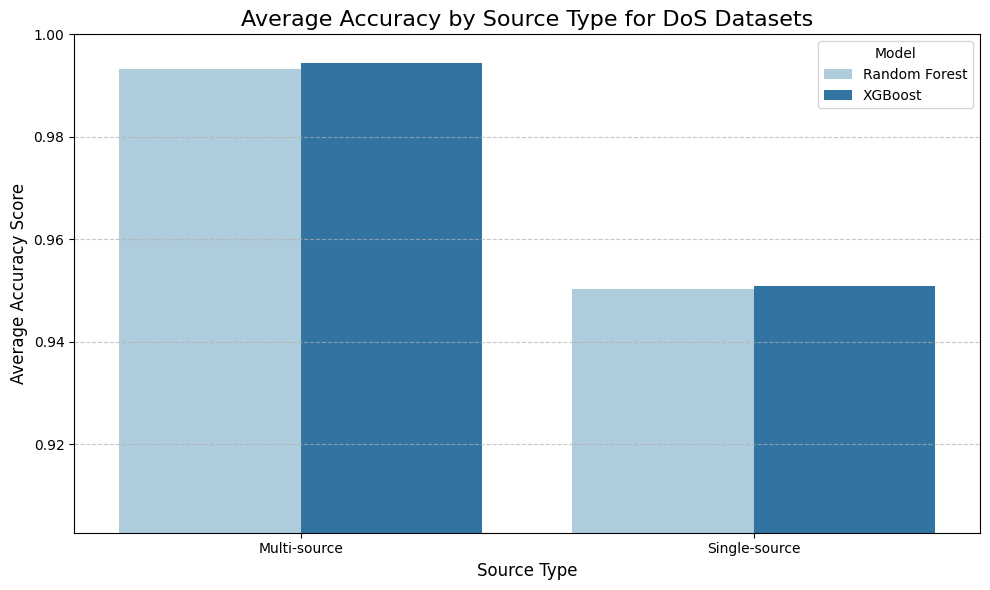

Average Accuracy: Single-source vs Multi-source (DoS) bar chart displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Re-define get_source_type function for robustness in this new cell
def get_source_type(file_name):
    single_source_patterns = [
        r'packet_flow', r'host_stats', r'syslog'
    ]
    multi_source_keywords = [
        'Host_stats', 'syslog', 'final', 'packet_Host', 'Host_syslog'
    ]
    normalized_file_name = file_name.lower().replace('.csv', '')

    if any(keyword in normalized_file_name for keyword in multi_source_keywords if keyword != 'syslog'):
        if ('packet_flow' in normalized_file_name and ('host_stats' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host_stats' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('packet' in normalized_file_name and ('host' in normalized_file_name or 'syslog' in normalized_file_name)) or \
           ('host' in normalized_file_name and 'syslog' in normalized_file_name) or \
           ('final' in normalized_file_name):
            return 'Multi-source'

    for pattern in single_source_patterns:
        if re.search(pattern, normalized_file_name) and not any(k in normalized_file_name for k in multi_source_keywords if k != 'syslog' and k not in pattern):
            return 'Single-source'
    return 'Unknown'

# Apply the function to create a new 'Source Type' column
results_df_classified_dos = results_df.copy()
results_df_classified_dos['Source Type'] = results_df_classified_dos['File Name'].apply(get_source_type)

# Filter for DoS related files and non-error models
dos_files_pattern = ['dos'] # Files containing 'dos' in their name
plot_df_classified_dos = results_df_classified_dos[
    results_df_classified_dos['File Name'].str.contains('|'.join(dos_files_pattern), case=False, regex=True) &
    (results_df_classified_dos['Model'] != 'Error')
].copy()
plot_df_classified_dos = plot_df_classified_dos[plot_df_classified_dos['Source Type'] != 'Unknown']

# Melt the DataFrame for plotting performance metrics (only Accuracy)
df_melted_source_comparison_dos = plot_df_classified_dos.melt(
    id_vars=['File Name', 'Model', 'Source Type'],
    value_vars=['Accuracy'],
    var_name='Metric',
    value_name='Score'
)

# Calculate average scores for each Source Type and Model for DoS datasets
mean_performance_by_source_dos = df_melted_source_comparison_dos.groupby(['Source Type', 'Model', 'Metric'])['Score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Source Type', y='Score', hue='Model', data=mean_performance_by_source_dos, palette='Paired')
plt.title('Average Accuracy by Source Type for DoS Datasets', fontsize=16)
plt.xlabel('Source Type', fontsize=12)
plt.ylabel('Average Accuracy Score', fontsize=12)
plt.ylim(mean_performance_by_source_dos['Score'].min() * 0.95, 1.0) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

print("Average Accuracy: Single-source vs Multi-source (DoS) bar chart displayed.")

### Accuracy Comparison for All DoS Datasets

This bar chart visualizes the accuracy scores of Random Forest and XGBoost models across all individual DoS-related datasets.

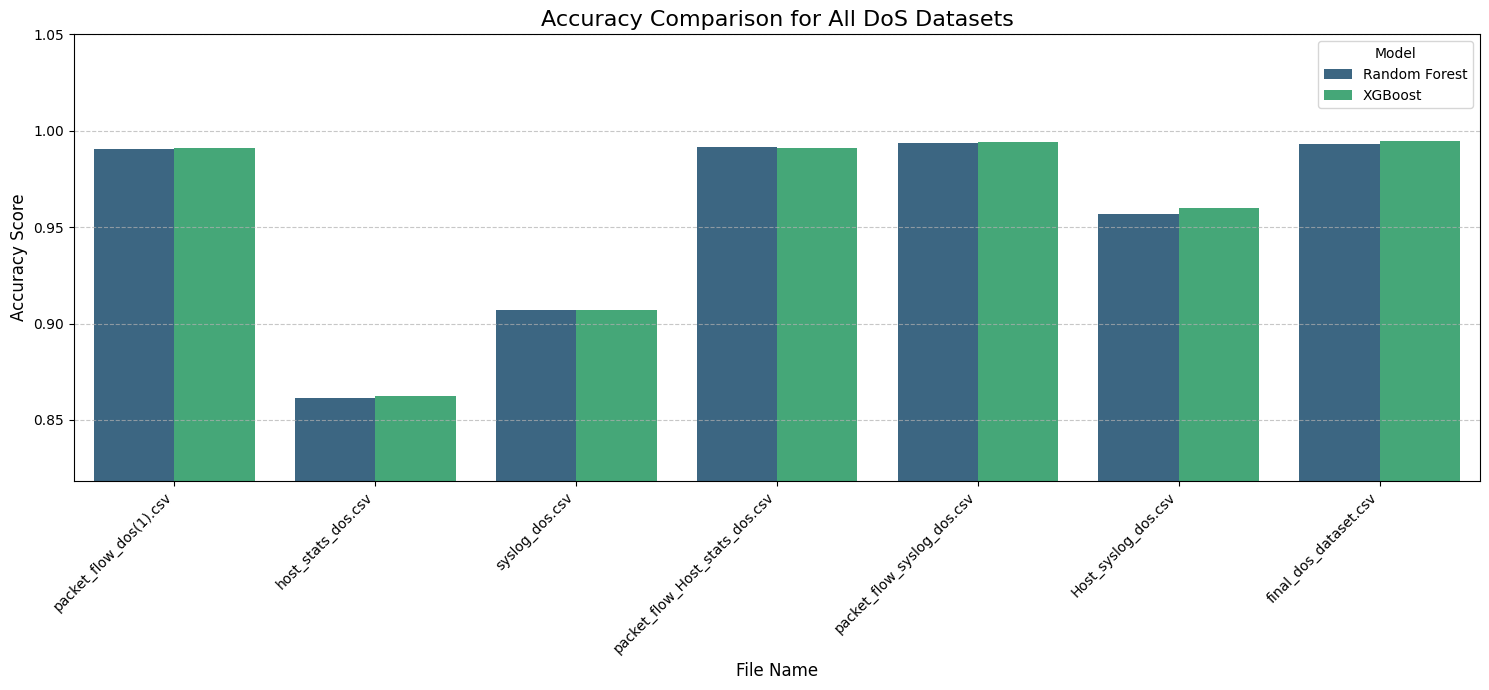

Accuracy Comparison for All DoS Datasets bar chart displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter results for all 'dos' files and valid models
dos_files_pattern = ['dos'] # Files containing 'dos' in their name
dos_performance_df = results_df[
    results_df['File Name'].str.contains('|'.join(dos_files_pattern), case=False, regex=True) &
    (results_df['Model'] != 'Error')
].copy()

plt.figure(figsize=(15, 7))
sns.barplot(x='File Name', y='Accuracy', hue='Model', data=dos_performance_df, palette='viridis')
plt.title('Accuracy Comparison for All DoS Datasets', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(dos_performance_df['Accuracy'].min() * 0.95, 1.05) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print("Accuracy Comparison for All DoS Datasets bar chart displayed.")

### Accuracy Comparison for All Ransomware Datasets

This bar chart visualizes the accuracy scores of Random Forest and XGBoost models across all individual ransomware-related datasets.

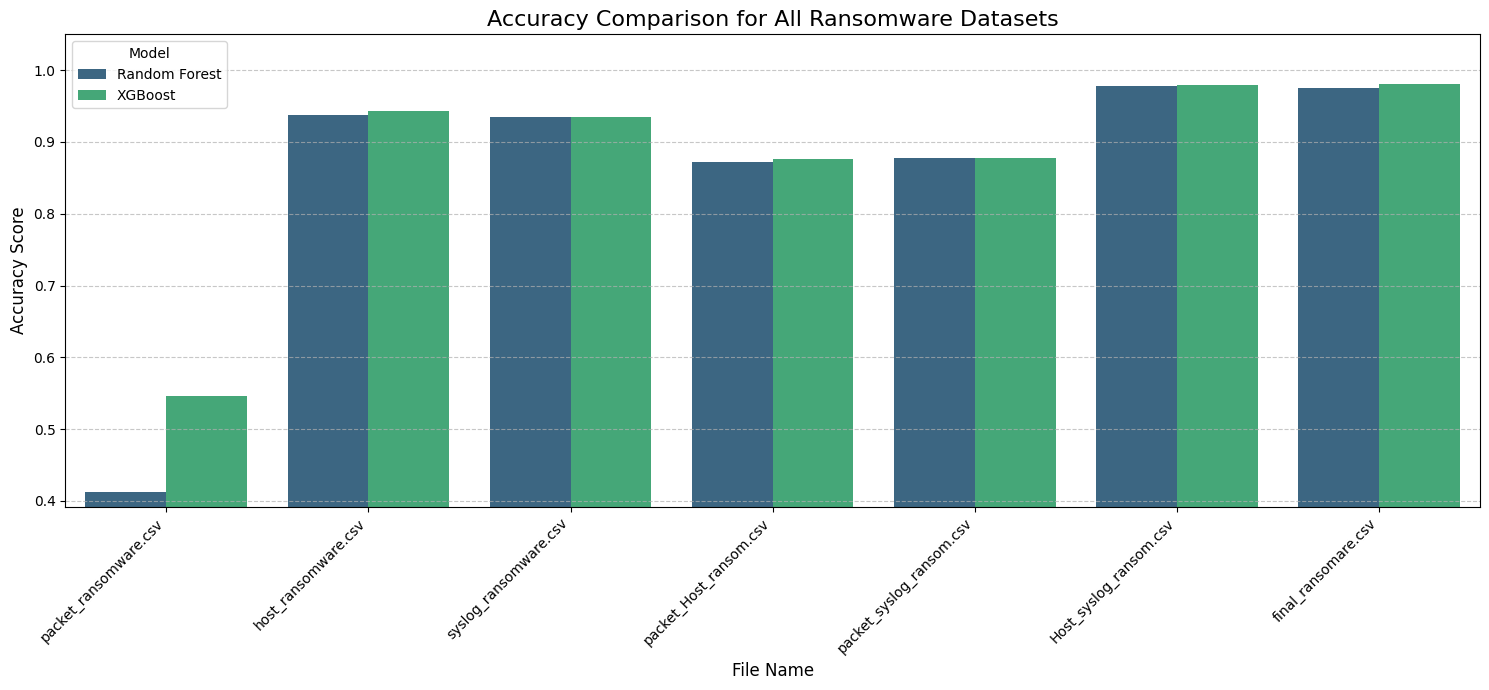

Accuracy Comparison for All Ransomware Datasets bar chart displayed.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter results for all 'ransomware' files and valid models
ransomware_files_pattern = ['ransomware', 'ransom'] # Files containing 'ransomware' or 'ransom' in their name
ransomware_performance_df = results_df[
    results_df['File Name'].str.contains('|'.join(ransomware_files_pattern), case=False, regex=True) &
    (results_df['Model'] != 'Error')
].copy()

plt.figure(figsize=(15, 7))
sns.barplot(x='File Name', y='Accuracy', hue='Model', data=ransomware_performance_df, palette='viridis')
plt.title('Accuracy Comparison for All Ransomware Datasets', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(ransomware_performance_df['Accuracy'].min() * 0.95, 1.05) # Adjust y-axis limits dynamically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print("Accuracy Comparison for All Ransomware Datasets bar chart displayed.")

### Hyperparameter Tuning for Random Forest using GridSearchCV

This section performs hyperparameter tuning for the Random Forest Classifier on the `final_dos_dataset.csv` and `final_ransomare.csv` using `GridSearchCV`. This helps in finding the optimal combination of parameters to improve model performance.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import os

# Assuming 'files' and 'find_label_column' function are available from previous cells

tuned_rf_results = []

print("Starting Random Forest Hyperparameter Tuning with GridSearchCV...")

# Filter for the final datasets
final_datasets = ['final_dos_dataset.csv', 'final_ransomare.csv']

for file in files:
    if file not in final_datasets:
        continue

    print(f"\n{'='*50}\nProcessing file for GridSearchCV: {file}\n{'='*50}")
    try:
        df = pd.read_csv(os.path.join('/content/', file))

        # Drop 'Unnamed: 0' column if it exists
        if 'Unnamed: 0' in df.columns:
            df.drop(columns=['Unnamed: 0'], inplace=True)

        label_col = find_label_column(df)
        if not label_col:
            print(f"Skipping {file}: No label column found.")
            continue

        # Separate features (X) and target (y)
        X = df.drop(columns=[label_col])
        y = df[label_col]

        # Convert target to binary (0 for normal/benign, 1 for attack)
        y = y.apply(lambda x: 0 if str(x).lower() in ['0', 'normal', 'benign'] else 1)

        # Handle categorical features using one-hot encoding
        X = pd.get_dummies(X, drop_first=True)

        # Replace infinite values with NaN before imputation
        X = X.replace([np.inf, -np.inf], np.nan)

        # Handle missing values (impute with median for numerical features)
        X = X.fillna(X.median())

        # Ensure all column names are strings and valid for XGBoost (also good practice for RF)
        X.columns = X.columns.astype(str)
        X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

        # Split data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping {file}: Not enough classes in train or test set after split.")
            continue

        # Define the parameter grid to search
        param_grid = {
            'n_estimators': [50, 100, 200], # Number of trees in the forest
            'max_depth': [None, 10, 20],   # Maximum depth of the tree
            'min_samples_leaf': [1, 5, 10] # Minimum number of samples required to be at a leaf node
        }

        # Initialize Random Forest Classifier
        rf = RandomForestClassifier(random_state=42, n_jobs=-1) # Use all available cores

        # Initialize GridSearchCV
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                                   cv=3, n_jobs=-1, verbose=1, scoring='f1')

        # Fit GridSearchCV to the training data
        grid_search.fit(X_train, y_train)

        # Get the best estimator
        best_rf_model = grid_search.best_estimator_

        print(f"\nBest parameters for {file}: {grid_search.best_params_}")

        # Evaluate the best model
        y_pred_tuned_rf = best_rf_model.predict(X_test)

        accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
        precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf, zero_division=0)
        recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf, zero_division=0)
        f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf, zero_division=0)

        print(f"Accuracy (Tuned RF): {accuracy_tuned_rf:.4f}")
        print(f"Precision (Tuned RF): {precision_tuned_rf:.4f}")
        print(f"Recall (Tuned RF): {recall_tuned_rf:.4f}")
        print(f"F1-Score (Tuned RF): {f1_tuned_rf:.4f}")
        print("Classification Report (Tuned RF):\n", classification_report(y_test, y_pred_tuned_rf, zero_division=0))

        tuned_rf_results.append({
            "File Name": file,
            "Model": "Random Forest (Tuned)",
            "Best Parameters": grid_search.best_params_,
            "Accuracy": accuracy_tuned_rf,
            "Precision": precision_tuned_rf,
            "Recall": recall_tuned_rf,
            "F1-Score": f1_tuned_rf
        })

    except Exception as e:
        print(f"An error occurred during GridSearchCV for {file}: {e}")
        tuned_rf_results.append({
            "File Name": file,
            "Model": "Random Forest (Tuned)",
            "Details": str(e)
        })

tuned_rf_df = pd.DataFrame(tuned_rf_results)
print("\n--- Tuned Random Forest Model Evaluation Summary ---")
display(tuned_rf_df)

Starting Random Forest Hyperparameter Tuning with GridSearchCV...

Processing file for GridSearchCV: final_dos_dataset.csv
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters for final_dos_dataset.csv: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Accuracy (Tuned RF): 0.9949
Precision (Tuned RF): 0.9920
Recall (Tuned RF): 0.9960
F1-Score (Tuned RF): 0.9940
Classification Report (Tuned RF):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      6006
           1       0.99      1.00      0.99      4494

    accuracy                           0.99     10500
   macro avg       0.99      1.00      0.99     10500
weighted avg       0.99      0.99      0.99     10500


Processing file for GridSearchCV: final_ransomare.csv
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Best parameters for final_ransomare.csv: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Accuracy (Tun

,File Name,Model,Best Parameters,Accuracy,Precision,Recall,F1-Score
0,final_dos_dataset.csv,Random Forest (Tuned),"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",0.994857,0.992021,0.995995,0.994004
1,final_ransomare.csv,Random Forest (Tuned),"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",0.980381,0.980564,0.980190,0.980377


### Tuned Random Forest Model Performance Summary

This table summarizes the performance metrics of the Random Forest models after hyperparameter tuning on the `final_dos_dataset.csv` and `final_ransomare.csv`.

In [ ]:
print('#### Tuned Random Forest Performance on Final Datasets')
display(tuned_rf_df.round(4).to_markdown(index=False))

### Overall Model Performance on Final Datasets (Before Tuning)

This table presents the performance metrics for both Random Forest and XGBoost models on the `final_dos_dataset.csv` and `final_ransomare.csv`, giving a concise overview of their initial effectiveness.

In [ ]:
# Filter results for the final datasets
final_datasets_performance = results_df[
    (results_df['File Name'] == 'final_dos_dataset.csv') |
    (results_df['File Name'] == 'final_ransomare.csv')
].copy()

# Select relevant columns for display
performance_display = final_datasets_performance[[
    'File Name', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]]

print('#### Overall Model Performance on Final Datasets (Untuned)')
display(performance_display.round(4).to_markdown(index=False))

### Average Performance Metrics by Model (Across All Datasets)

This table presents the average performance metrics for Random Forest and XGBoost across all datasets, offering a high-level comparison of their overall effectiveness.

In [ ]:
comparison_df = results_df[results_df['Model'] != 'Error'][[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
]].copy()

# Group by model and calculate the mean for each metric
summary_comparison = comparison_df.groupby('Model').mean().round(4)

print('#### Average Performance Metrics by Model')
display(summary_comparison.to_markdown())

### Confusion Matrix Metrics Across Datasets

This table presents a detailed breakdown of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN) for each model across all datasets, providing a granular view of each model's classification performance.

In [ ]:
confusion_matrix_summary_impress = []

for index, row in results_df.iterrows():
    file_name = row['File Name']
    model_name = row['Model']
    cm = row['Confusion Matrix']

    if cm and isinstance(cm, list) and len(cm) == 2 and all(isinstance(r, list) and len(r) == 2 for r in cm):
        tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

        confusion_matrix_summary_impress.append({
            "File Name": file_name,
            "Model": model_name,
            "True Negatives (TN)": tn,
            "False Positives (FP)": fp,
            "False Negatives (FN)": fn,
            "True Positives (TP)": tp
        })
    elif model_name != 'Error':
        confusion_matrix_summary_impress.append({
            "File Name": file_name,
            "Model": model_name,
            "True Negatives (TN)": "N/A",
            "False Positives (FP)": "N/A",
            "False Negatives (FN)": "N/A",
            "True Positives (TP)": "N/A",
            "Details": "Invalid or missing Confusion Matrix"
        })

cm_summary_df_impress = pd.DataFrame(confusion_matrix_summary_impress)
print('#### Confusion Matrix Metrics Across Datasets')
display(cm_summary_df_impress.to_markdown(index=False))

#### Confusion Matrix Metrics Across Datasets


'| File Name                      | Model         |   True Negatives (TN) |   False Positives (FP) |   False Negatives (FN) |   True Positives (TP) |\n|:-------------------------------|:--------------|----------------------:|-----------------------:|-----------------------:|----------------------:|\n| packet_flow_dos(1).csv         | Random Forest |                  5935 |                     71 |                     29 |                  4483 |\n| packet_flow_dos(1).csv         | XGBoost       |                  5939 |                     67 |                     27 |                  4485 |\n| host_stats_dos.csv             | Random Forest |                  5201 |                     49 |                   1404 |                  3846 |\n| host_stats_dos.csv             | XGBoost       |                  5206 |                     44 |                   1402 |                  3848 |\n| syslog_dos.csv                 | Random Forest |                  4991 |                    259 |

### Top 5 Feature Importances for Final Datasets (Random Forest)

These tables show the top 5 most important features identified by the Random Forest models for the `final_dos_dataset.csv` and `final_ransomare.csv`. These features were most influential in the models' predictions, providing valuable insights into the datasets.

In [ ]:
# Filter for Random Forest models on final datasets
rf_final_datasets_impress = results_df[
    ((results_df['File Name'] == 'final_dos_dataset.csv') |
     (results_df['File Name'] == 'final_ransomare.csv')) &
    (results_df['Model'] == 'Random Forest')
].copy()

for index, row in rf_final_datasets_impress.iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        print(f"\n#### Top 5 Feature Importances for {file_name} (Random Forest)")
        # Convert to DataFrame for better display and sorting
        importance_df_impress = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df_impress = importance_df_impress.sort_values(by='Importance', ascending=False).head(5)
        display(importance_df_impress.round(4).to_markdown(index=False))
    else:
        print(f"\nNo feature importances found for {file_name} (Random Forest).")


#### Top 5 Feature Importances for final_dos_dataset.csv (Random Forest)


'| Feature             |   Importance |\n|:--------------------|-------------:|\n| BwdPacketLengthStd  |       0.1527 |\n| AveragePacketSize   |       0.1202 |\n| BwdPacketLengthMax  |       0.1028 |\n| BwdPacketLengthMean |       0.0953 |\n| AvgBwdSegmentSize   |       0.0683 |'


#### Top 5 Feature Importances for final_ransomare.csv (Random Forest)


'| Feature     |   Importance |\n|:------------|-------------:|\n| Disk_Write  |       0.3398 |\n| CPU         |       0.2248 |\n| file_access |       0.0832 |\n| sudo_usage  |       0.0766 |\n| Page_Faults |       0.0673 |'

### Saving All Outputs to Files

This section generates code to save all the key DataFrames as CSV files and all the generated plots as PNG images. All files will be saved in a new directory named `/content/outputs/`.

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a directory to save outputs
output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)
print(f'Output directory created: {output_dir}')

Output directory created: /content/outputs


#### Saving DataFrame Outputs

In [ ]:
# Save the initial data summary DataFrame
result.to_csv(os.path.join(output_dir, 'data_summary.csv'), index=False)
print("Saved 'data_summary.csv'")

# Save the overall model evaluation summary DataFrame
results_df.to_csv(os.path.join(output_dir, 'model_evaluation_summary.csv'), index=False)
print("Saved 'model_evaluation_summary.csv'")

# Save the performance on final datasets DataFrame
performance_display.to_csv(os.path.join(output_dir, 'final_datasets_performance.csv'), index=False)
print("Saved 'final_datasets_performance.csv'")

# Save the average performance metrics by model DataFrame
summary_comparison.to_csv(os.path.join(output_dir, 'average_model_performance.csv'), index=True)
print("Saved 'average_model_performance.csv'")

# Save the confusion matrix metrics DataFrame
cm_summary_df.to_csv(os.path.join(output_dir, 'confusion_matrix_metrics.csv'), index=False)
print("Saved 'confusion_matrix_metrics.csv'")

# Save the tuned Random Forest model evaluation summary DataFrame
tuned_rf_df.to_csv(os.path.join(output_dir, 'tuned_rf_summary.csv'), index=False)
print("Saved 'tuned_rf_summary.csv'")

Saved 'data_summary.csv'
Saved 'model_evaluation_summary.csv'
Saved 'final_datasets_performance.csv'
Saved 'average_model_performance.csv'
Saved 'confusion_matrix_metrics.csv'
Saved 'tuned_rf_summary.csv'


#### Saving Plot Outputs

In [ ]:
# 1. Distribution of Normal and Attack Labels Across Files
df_melted = result.melt(id_vars=['File Name'], value_vars=['Normal', 'Attack'], var_name='Label Type', value_name='Count')
plt.figure(figsize=(18, 8))
sns.barplot(x='File Name', y='Count', hue='Label Type', data=df_melted)
plt.title('Distribution of Normal and Attack Labels Across Files', fontsize=16)
plt.xlabel('File Name', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Label Type', fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'normal_attack_distribution.png'))
plt.close()
print("Saved 'normal_attack_distribution.png'")

Saved 'normal_attack_distribution.png'


In [ ]:
# 2. Top 10 Feature Importances for each file (Random Forest)
rf_results_for_plots = results_df[results_df['Model'] == 'Random Forest'].copy()

for index, row in rf_results_for_plots.iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        importance_df_plot = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df_plot = importance_df_plot.sort_values(by='Importance', ascending=False).head(10)

        plt.figure(figsize=(12, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')
        plt.title(f'Top 10 Feature Importances for {file_name} (Random Forest)', fontsize=16)
        plt.xlabel('Importance', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.tight_layout()
        safe_file_name = file_name.replace('.csv', '').replace(' ', '_').replace('(', '').replace(')', '')
        plt.savefig(os.path.join(output_dir, f'top10_features_{safe_file_name}_rf.png'))
        plt.close()
        print(f"Saved 'top10_features_{safe_file_name}_rf.png'")

/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')


Saved 'top10_features_packet_flow_dos1_rf.png'


/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')
/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')


Saved 'top10_features_host_stats_dos_rf.png'
Saved 'top10_features_syslog_dos_rf.png'


/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')


...

Saved 'top10_features_packet_syslog_ransom_rf.png'


/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')


Saved 'top10_features_Host_syslog_ransom_rf.png'


/tmp/ipykernel_6354/3290005900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_plot, palette='viridis')


Saved 'top10_features_final_ransomare_rf.png'


In [ ]:
# 3. Comparison of Model Performance Across Files (Catplot)
plot_df = results_df[results_df['Model'] != 'Error'].copy()
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_melted_metrics = plot_df.melt(id_vars=['File Name', 'Model'], value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

g = sns.catplot(
    x='File Name',
    y='Score',
    hue='Model',
    col='Metric',
    data=df_melted_metrics,
    kind='bar',
    col_wrap=2,
    height=5,
    aspect=1.8,
    palette='viridis',
    sharey=False
)

g.set_axis_labels('File Name', 'Score')
g.set_xticklabels(rotation=45, ha='right')
g.set_titles('Metric: {col_name}')
g.fig.suptitle('Comparison of Model Performance Across Files', y=1.02, fontsize=18)
g.add_legend(title='Model')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(os.path.join(output_dir, 'model_performance_comparison_catplot.png'))
plt.close()
print("Saved 'model_performance_comparison_catplot.png'")

Saved 'model_performance_comparison_catplot.png'


In [ ]:
# 4. Accuracy Comparison Across All Datasets by Model (Box Plot)
plot_accuracy_df = results_df[results_df['Model'] != 'Error'][['Model', 'Accuracy']].copy()
plt.figure(figsize=(10, 6))
sns.boxplot(x='Model', y='Accuracy', data=plot_accuracy_df, palette='pastel', hue='Model', legend=False)
plt.title('Accuracy Comparison Across All Datasets by Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'accuracy_comparison_boxplot.png'))
plt.close()
print("Saved 'accuracy_comparison_boxplot.png'")

Saved 'accuracy_comparison_boxplot.png'


In [ ]:
# 5. Confusion Matrix Heatmaps for Random Forest Models
rf_results_cm = results_df[results_df['Model'] == 'Random Forest'].copy()
for index, row in rf_results_cm.iterrows():
    file_name = row['File Name']
    cm = row['Confusion Matrix']

    if cm and isinstance(cm, list) and len(cm) == 2 and all(isinstance(r, list) and len(r) == 2 for r in cm):
        cm_array = np.array(cm)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Predicted 0 (Normal)', 'Predicted 1 (Attack)'],
                    yticklabels=['Actual 0 (Normal)', 'Actual 1 (Attack)'],
                    linewidths=.5, linecolor='black')
        plt.title(f'Confusion Matrix: {file_name} (Random Forest)', fontsize=14)
        plt.ylabel('Actual Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.tight_layout()
        safe_file_name = file_name.replace('.csv', '').replace(' ', '_').replace('(', '').replace(')', '')
        plt.savefig(os.path.join(output_dir, f'confusion_matrix_{safe_file_name}_rf.png'))
        plt.close()
        print(f"Saved 'confusion_matrix_{safe_file_name}_rf.png'")

Saved 'confusion_matrix_packet_flow_dos1_rf.png'
Saved 'confusion_matrix_host_stats_dos_rf.png'
Saved 'confusion_matrix_syslog_dos_rf.png'
Saved 'confusion_matrix_packet_flow_Host_stats_dos_rf.png'
Saved 'confusion_matrix_packet_flow_syslog_dos_rf.png'
Saved 'confusion_matrix_Host_syslog_dos_rf.png'
Saved 'confusion_matrix_final_dos_dataset_rf.png'
Saved 'confusion_matrix_packet_ransomware_rf.png'
Saved 'confusion_matrix_host_ransomware_rf.png'
Saved 'confusion_matrix_syslog_ransomware_rf.png'
Saved 'confusion_matrix_packet_Host_ransom_rf.png'
Saved 'confusion_matrix_packet_syslog_ransom_rf.png'
Saved 'confusion_matrix_Host_syslog_ransom_rf.png'
Saved 'confusion_matrix_final_ransomare_rf.png'


In [ ]:
# 6. Average Accuracy Comparison: Random Forest vs. XGBoost (Bar Chart)
# Ensure summary_comparison DataFrame is available and correctly structured
# If it's not from previous execution, re-create it for robustness
if 'summary_comparison' not in locals():
    comparison_df = results_df[results_df['Model'] != 'Error'][[
        'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'
    ]].copy()
    summary_comparison = comparison_df.groupby('Model').mean().round(4)

plt.figure(figsize=(8, 6))
sns.barplot(x=summary_comparison.index, y='Accuracy', data=summary_comparison, palette='viridis', hue=summary_comparison.index, legend=False)
plt.title('Average Accuracy Comparison: Random Forest vs. XGBoost', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average Accuracy', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'average_accuracy_barplot.png'))
plt.close()
print("Saved 'average_accuracy_barplot.png'")

Saved 'average_accuracy_barplot.png'


In [ ]:
# 7. Comparison of Top 5 Feature Importances by Dataset (Random Forest) - Final Datasets
rf_final_datasets_plot = results_df[
    ((results_df['File Name'] == 'final_dos_dataset.csv') |
     (results_df['File Name'] == 'final_ransomare.csv')) &
    (results_df['Model'] == 'Random Forest')
].copy()

all_top_features_plot = []

for index, row in rf_final_datasets_plot.iterrows():
    file_name = row['File Name']
    feature_importances = row['Feature Importances']

    if feature_importances:
        importance_df_combined = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
        importance_df_combined = importance_df_combined.sort_values(by='Importance', ascending=False).head(5)
        importance_df_combined['Dataset'] = file_name
        all_top_features_plot.append(importance_df_combined)

if all_top_features_plot:
    combined_importance_df_plot = pd.concat(all_top_features_plot)
    g_combined = sns.catplot(
        x='Importance',
        y='Feature',
        col='Dataset',
        data=combined_importance_df_plot,
        kind='bar',
        col_wrap=2,
        height=6,
        aspect=1.2,
        palette='viridis',
        sharex=False
    )

    g_combined.set_axis_labels('Importance', 'Feature')
    g_combined.set_titles('Top 5 Features for {col_name}')
    g_combined.fig.suptitle('Comparison of Top 5 Feature Importances by Dataset (Random Forest)', y=1.02, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(os.path.join(output_dir, 'top5_features_final_datasets_rf_comparison.png'))
    plt.close()
    print("Saved 'top5_features_final_datasets_rf_comparison.png'")
else:
    print("No feature importances found to compare for the final datasets to plot.")

/tmp/ipykernel_6354/1133989959.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g_combined = sns.catplot(


Saved 'top5_features_final_datasets_rf_comparison.png'


All outputs have been saved to the `/content/outputs/` directory. You can access and download them from the file browser on the left.

In [ ]:
import os

# Get the list of files that should be processed from the 'files' variable
expected_files = files # 'files' is already defined in cell EXnwk6kNpvhS

# Get the list of actual files in the /content/ directory
actual_content_files = os.listdir('/content/')

print("--- Checking for Missing CSV Files ---")

missing_files = []
for file in expected_files:
    if file not in actual_content_files:
        missing_files.append(file)

if missing_files:
    print("The following required CSV files are MISSING from the /content/ directory:")
    for f in missing_files:
        print(f"- {f}")
    print("\nPlease upload these files to the /content/ directory to proceed.")
else:
    print("All required CSV files are present in the /content/ directory.")

print("\n--- Files currently in /content/ ---")
for f in actual_content_files:
    print(f"- {f}")

--- Checking for Missing CSV Files ---
All required CSV files are present in the /content/ directory.

--- Files currently in /content/ ---
- .config
- Host_syslog_dos.csv
- packet_flow_syslog_dos.csv
- packet_syslog_ransom.csv
- packet_ransomware.csv
- syslog_ransomware.csv
- final_ransomare.csv
- Host_syslog_ransom.csv
- packet_Host_ransom.csv
- host_ransomware.csv
- final_dos_dataset.csv
- host_stats_dos.csv
- syslog_dos.csv
- outputs
- packet_flow_Host_stats_dos.csv
- packet_flow_dos(1).csv
- sample_data
